# Trabajo Práctico AA1 - Clasificación

In [358]:
%%capture
%pip install -r requirements.txt

In [359]:
import sys
print(sys.executable)

import tensorflow as tf
print(tf.__version__)

c:\Valentin\TUIA\Aprendisaje Automatico I\AA1-TUIA-Dimenna-Jacob-Taborda\.venv\Scripts\python.exe
2.21.0


In [360]:
# manipulación, visualización y modelado.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

# separación de datos, modelos y métricas.
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, roc_auc_score, auc
import warnings
warnings.simplefilter('ignore')
import optuna
import tensorflow as tf

# preprocesamiento.
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# geolocalización y visualización de ubicaciones.
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
from folium import Map, Marker, Icon
from sklearn.cluster import KMeans
from pycaret.classification import *

## Ítem 1: Análisis descriptivo

In [361]:
# Cargamos el dataset
df_original = pd.read_csv("./content/weatherAUS_2026C1.csv")
df_original.head()

,Unnamed: 0,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,RainfallTomorrow
0,0,2008-12-01,Albury,13.6,22.5,0.6,NaN,NaN,W,45.0,...,23.8,1008.1,1007.2,8.0,NaN,16.8,20.8,No,No,0.0
1,1,2008-12-02,Albury,7.3,25.8,0.0,NaN,NaN,WNW,44.0,...,22.1,1011.1,1007.5,NaN,NaN,18.3,24.6,No,No,0.0
2,2,2008-12-03,Albury,13.2,26.2,0.0,NaN,NaN,WSW,46.0,...,31.5,1007.3,1009.4,NaN,2.0,21.2,23.4,No,No,0.0
3,3,2008-12-04,Albury,10.0,28.8,0.0,NaN,NaN,NE,23.0,...,18.5,1017.6,1012.4,NaN,NaN,17.4,26.3,No,No,1.0
4,4,2008-12-05,Albury,17.4,32.4,1.0,NaN,NaN,W,41.0,...,34.6,1010.9,1005.9,7.0,8.0,17.9,29.1,No,No,0.2


In [362]:
#copiamos el dataset para mantener el original
df = df_original.copy()

In [363]:
# revisamos las columnas
df.columns

Index(['Unnamed: 0', 'Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall',
       'Evaporation', 'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am',
       'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
       'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm',
       'Temp9am', 'Temp3pm', 'RainToday', 'RainTomorrow', 'RainfallTomorrow'],
      dtype='object')

In [364]:
# revisamos cantidad de filas y columnas
df.shape

(145412, 25)

In [365]:
# revisamos tipos de datos y valores no nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145412 entries, 0 to 145411
Data columns (total 25 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        145412 non-null  int64  
 1   Date              145412 non-null  object 
 2   Location          145412 non-null  object 
 3   MinTemp           143928 non-null  float64
 4   MaxTemp           144159 non-null  float64
 5   Rainfall          142152 non-null  float64
 6   Evaporation       82658 non-null   float64
 7   Sunshine          75616 non-null   float64
 8   WindGustDir       135096 non-null  object 
 9   WindGustSpeed     135159 non-null  float64
 10  WindDir9am        134850 non-null  object 
 11  WindDir3pm        141186 non-null  object 
 12  WindSpeed9am      143645 non-null  float64
 13  WindSpeed3pm      142351 non-null  float64
 14  Humidity9am       142759 non-null  float64
 15  Humidity3pm       140907 non-null  float64
 16  Pressure9am       13

### Descripción de variables

- Date: fecha de la observación.
- Location: ciudad o estación meteorológica donde se tomó la observación.
- MinTemp: temperatura mínima registrada durante el día.
- MaxTemp: temperatura máxima registrada durante el día.
- Rainfall: cantidad de lluvia registrada durante el día.
- Evaporation: evaporación registrada.
- Sunshine: cantidad de horas de sol.
- WindGustDir: dirección de la ráfaga de viento más fuerte.
- WindGustSpeed: velocidad de la ráfaga de viento más fuerte.
- WindDir9am: dirección del viento a las 9am.
- WindDir3pm: dirección del viento a las 3pm.
- WindSpeed9am: velocidad del viento a las 9am.
- WindSpeed3pm: velocidad del viento a las 3pm.
- Humidity9am: humedad a las 9am.
- Humidity3pm: humedad a las 3pm.
- Pressure9am: presión atmosférica a las 9am.
- Pressure3pm: presión atmosférica a las 3pm.
- Cloud9am: nubosidad a las 9am.
- Cloud3pm: nubosidad a las 3pm.
- Temp9am: temperatura a las 9am.
- Temp3pm: temperatura a las 3pm.
- RainToday: indica si llovió durante el día actual.
- RainTomorrow: variable objetivo; indica si llovió al día siguiente.
- RainfallTomorrow: Cantidad de lluvia al día siguiente

In [366]:
df.isnull().sum()

Unnamed: 0              0
Date                    0
Location                0
MinTemp              1484
MaxTemp              1253
Rainfall             3260
Evaporation         62754
Sunshine            69796
WindGustDir         10316
WindGustSpeed       10253
WindDir9am          10562
WindDir3pm           4226
WindSpeed9am         1767
WindSpeed3pm         3061
Humidity9am          2653
Humidity3pm          4505
Pressure9am         15061
Pressure3pm         15024
Cloud9am            55870
Cloud3pm            59336
Temp9am              1766
Temp3pm              3607
RainToday            3260
RainTomorrow         3259
RainfallTomorrow     3259
dtype: int64

Se detectan valores faltantes en varias columnas, por lo que será necesario tratarlo según el caso.

In [367]:
df = df.drop(columns=["Unnamed: 0"])

La columna "Unnamed: 0" parece ser un índice guardado en el archivo CSV, por lo que no representa una variable climática útil para la predicción. Por este motivo se elimina del análisis.

In [368]:
df = df.drop(columns=["RainfallTomorrow"])

In [369]:
# verificamos que hayan sido eliminadas
df.columns

Index(['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation',
       'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'RainToday', 'RainTomorrow'],
      dtype='object')

La columna "RainfallTomorrow" no se utiliza como variable predictora porque contiene información asociada al día siguiente. Como el objetivo es predecir a las 23:59 hs si al día siguiente lloverá o no, esta información no estaría disponible al momento de realizar la predicción. Usarla produciría fuga de datos.

### EDA

### Locations

In [370]:
def CamelCase(cadena: str) -> str:
  """
  Funcion para modificar el nombre de las variables porque sino tira error por como esta hecha.
  """
  resultado = ""
  for i, caracter in enumerate(cadena):
    #print(i,caracter)
    if i > 0 and caracter.isupper() and cadena[i-1].islower():
      resultado += " "
    resultado += caracter
  return resultado

In [371]:
ciudades = df['Location'].unique()
geolocator = Nominatim(user_agent="climate_region_clustering", timeout=10)
geocode = RateLimiter(
    geolocator.geocode,
    min_delay_seconds=1.2,
    max_retries=3,
    error_wait_seconds=5,
    swallow_exceptions=True,
    return_value_on_exception=None
)
# Obtener coordenadas
coords = []
contador = 0
print("Obteniendo coordenadas de las ciudades...")
for ciudad in ciudades:
  location = geocode(f"{CamelCase(ciudad)}, Australia")
  #print(location)
  if location:
    lat = location.latitude
    lon = location.longitude
    coords.append((ciudad, lat, lon))
    contador += 1
  else:
    print(f"No se encontró: {ciudad}")
    coords.append((ciudad, None, None))

df_coords = pd.DataFrame(coords, columns=["Location", "Latitude", "Longitude"])
print(f"Se cargaron correctamente {contador} ciudades.")

Obteniendo coordenadas de las ciudades...
Se cargaron correctamente 49 ciudades.


In [372]:
df_coords.head(54)

,Location,Latitude,Longitude
0,Albury,-36.073773,146.913526
1,BadgerysCreek,-33.883145,150.742466
2,Cobar,-31.966663,145.304505
3,CoffsHarbour,-30.298600,153.109412
4,Moree,-29.461720,149.840715
5,Newcastle,-32.919295,151.779535
6,NorahHead,-33.281667,151.567778
7,NorfolkIsland,-29.032804,167.948314
8,Penrith,-33.751195,150.694171
9,Richmond,-37.807450,144.990721


In [373]:
map = Map(location=[-25.0, 133.0], zoom_start=4)
for _, row in df_coords.iterrows():
  Marker(location=[row['Latitude'], row['Longitude']], popup=row['Location'], icon=Icon()).add_to(map)
map

Ahora que tenemos las coordenadas y las ciudades ubicadas, las agrupamos en Regiones

In [374]:
# Aplicar KMeans sobre latitud y longitud
kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
df_coords["Region"] = kmeans.fit_predict(df_coords[["Latitude", "Longitude"]])

In [375]:
colores = ['red', 'pink', 'green', 'purple', 'orange', 'darkred', 'darkgreen', 'darkblue', 'black', 'blue']

map = Map(location=[-25.0, 133.0], zoom_start=4)
for _, row in df_coords.iterrows():
  # Elegir el color según el cluster
  color = colores[row['Region'] % len(colores)]
  Marker(location=[row['Latitude'], row['Longitude']], popup=f"{row['Location']} (Cluster {row['Region']})", icon=Icon(color=color)).add_to(map)
map

In [376]:
# Agregar Region al df original
df = df.merge(df_coords[['Location', 'Region']], on='Location', how='left')

In [377]:
df

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Region
0,2008-12-01,Albury,13.6,22.5,0.6,NaN,NaN,W,45.0,W,...,23.8,1008.1,1007.2,8.0,NaN,16.8,20.8,No,No,9
1,2008-12-02,Albury,7.3,25.8,0.0,NaN,NaN,WNW,44.0,NNW,...,22.1,1011.1,1007.5,NaN,NaN,18.3,24.6,No,No,9
2,2008-12-03,Albury,13.2,26.2,0.0,NaN,NaN,WSW,46.0,W,...,31.5,1007.3,1009.4,NaN,2.0,21.2,23.4,No,No,9
3,2008-12-04,Albury,10.0,28.8,0.0,NaN,NaN,NE,23.0,SE,...,18.5,1017.6,1012.4,NaN,NaN,17.4,26.3,No,No,9
4,2008-12-05,Albury,17.4,32.4,1.0,NaN,NaN,W,41.0,ENE,...,34.6,1010.9,1005.9,7.0,8.0,17.9,29.1,No,No,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145407,2017-06-20,Uluru,2.6,22.0,0.0,NaN,NaN,E,29.0,ESE,...,26.5,1024.8,1021.2,NaN,NaN,10.1,21.6,No,No,8
145408,2017-06-21,Uluru,3.1,23.2,0.0,NaN,NaN,E,31.0,SE,...,24.7,1024.3,1020.5,NaN,NaN,11.1,21.5,No,No,8
145409,2017-06-22,Uluru,3.6,26.0,0.0,NaN,NaN,NNW,21.0,SE,...,21.4,1023.3,1018.4,NaN,NaN,11.8,24.5,No,No,8
145410,2017-06-23,Uluru,4.8,27.4,0.0,NaN,NaN,N,39.0,SE,...,23.7,1021.0,1016.0,NaN,NaN,12.0,26.9,No,No,8


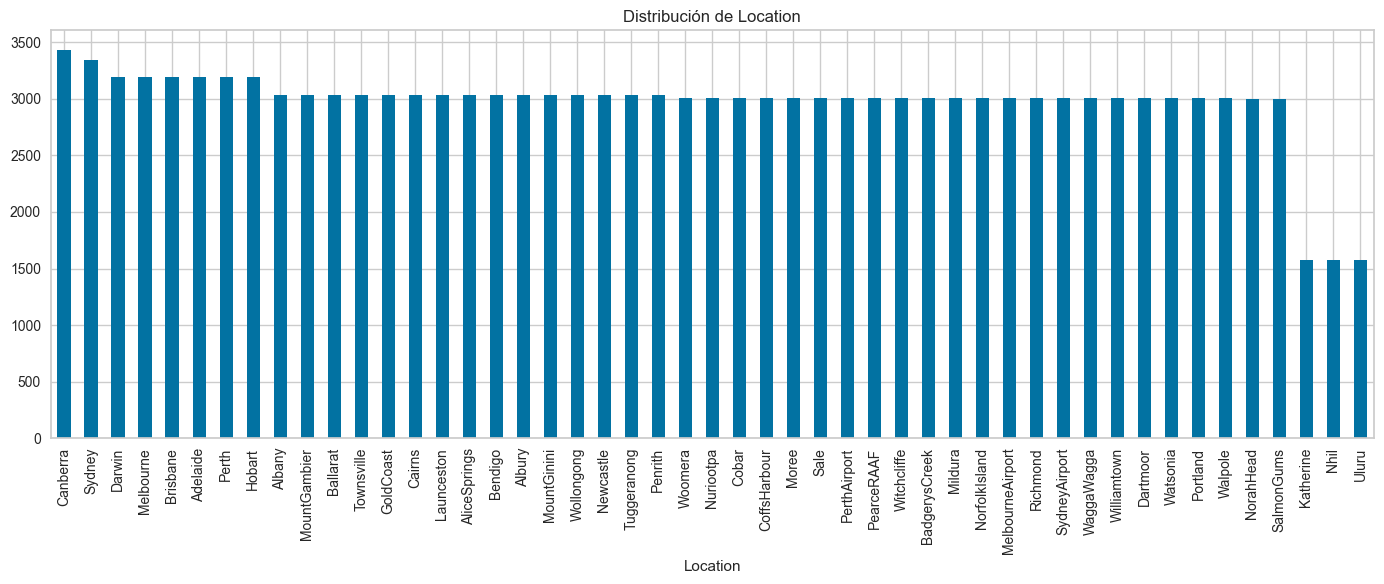

In [378]:
df['Location'].value_counts().plot(kind='bar', figsize=(14, 6))
plt.title("Distribución de Location")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [379]:
df = df.drop(columns=['Location'])

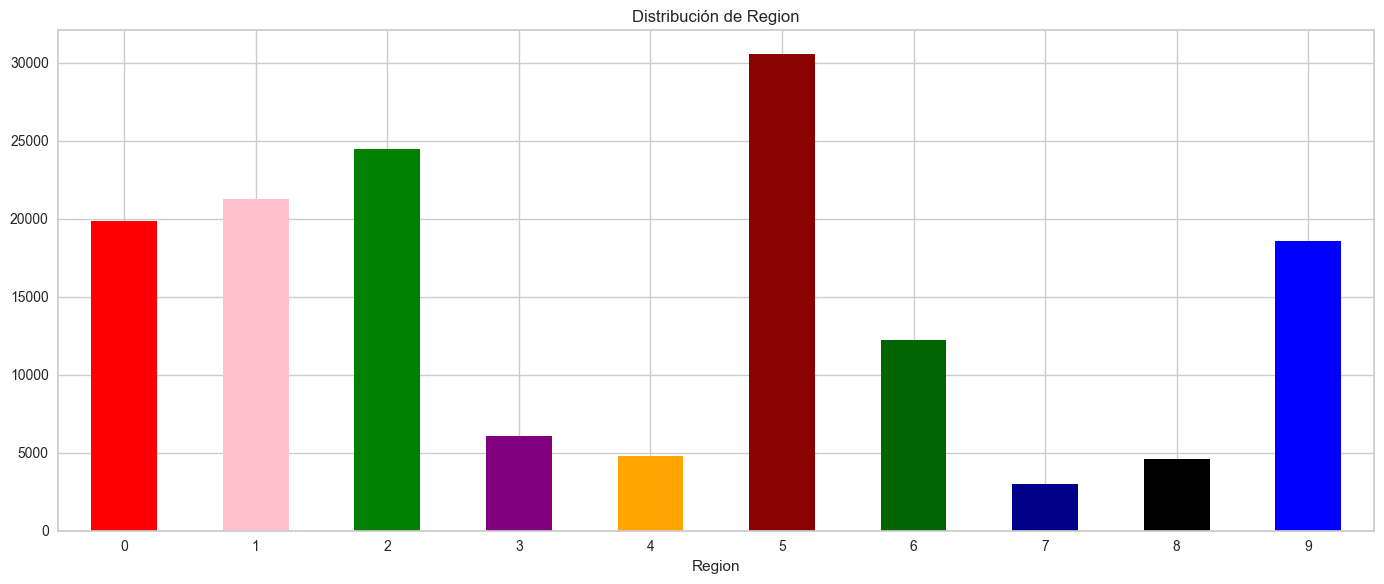

In [380]:
df['Region'].value_counts().sort_index().plot(kind='bar', figsize=(14, 6), color=colores)
plt.title("Distribución de Region")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [381]:
# revisamos los valores de la variable objetivo
df["RainTomorrow"].value_counts(dropna=False)

RainTomorrow
No     110281
Yes     31872
NaN      3259
Name: count, dtype: int64

In [382]:
# Calculamos la proporción de cada clase
df["RainTomorrow"].value_counts(normalize=True, dropna=False)

RainTomorrow
No     0.758404
Yes    0.219184
NaN    0.022412
Name: proportion, dtype: float64

In [383]:
# eliminamos filas donde la variable objetivo no tiene valor
df = df.dropna(subset=["RainTomorrow"])
# verificamos
df["RainTomorrow"].value_counts(dropna=False)

RainTomorrow
No     110281
Yes     31872
Name: count, dtype: int64

In [384]:
df_nuevo = df.copy()

In [385]:
# separamos variables predictoras y variable objetivo.
X = df_nuevo.drop(columns=["RainTomorrow"])
y = df_nuevo["RainTomorrow"]

In [386]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [387]:
df_train = pd.concat([X_train, y_train], axis=1)
df_test = pd.concat([X_test, y_test], axis=1)

In [388]:
print(len(X_train))
print(len(X_test))
print(len(y_train))
print(len(y_test))

113722
28431
113722
28431


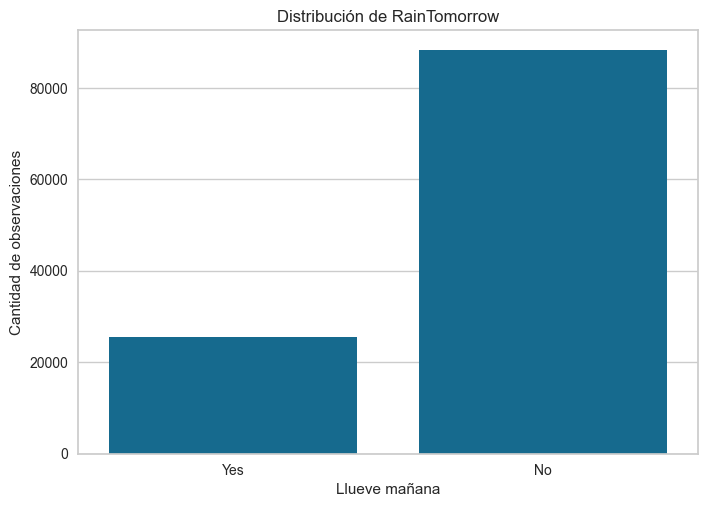

In [389]:
# Graficamos la distribución de la variable objetivo
sns.countplot(data=df_train,x="RainTomorrow", order=["Yes", "No"])
plt.title("Distribución de RainTomorrow")
plt.xlabel("Llueve mañana")
plt.ylabel("Cantidad de observaciones")
plt.show()

La variable objetivo del problema es "RainTomorrow", que indica si al día siguiente llovió o no. En distribución observamos que la clase "No" aparece con mucha mayor frecuencia que la clase "Yes". Por ende el dataset está desbalanceado, por este motivo, además de accuracy, será necesario observar métricas como precision, recall y F1-score, especialmente para la clase "Yes". Sino el modelo puede no aprender a detectar bien los dias que si llueve


Las filas con valores faltantes en "RainTomorrow" se eliminan porque esta columna es la variable objetivo. Si no se conoce si al día siguiente llovió o no, esa observación no puede utilizarse para entrenar ni evaluar un modelo supervisado.

In [390]:
df_train.dtypes

Date              object
MinTemp          float64
MaxTemp          float64
Rainfall         float64
Evaporation      float64
Sunshine         float64
WindGustDir       object
WindGustSpeed    float64
WindDir9am        object
WindDir3pm        object
WindSpeed9am     float64
WindSpeed3pm     float64
Humidity9am      float64
Humidity3pm      float64
Pressure9am      float64
Pressure3pm      float64
Cloud9am         float64
Cloud3pm         float64
Temp9am          float64
Temp3pm          float64
RainToday         object
Region             int32
RainTomorrow      object
dtype: object

In [391]:
# calculamos cantidad y porcentaje de valores faltantes por columna
faltantes = pd.DataFrame({
    "cantidad_faltantes": df_train.isna().sum(),
    "porcentaje_faltantes": df_train.isna().mean() * 100
})

faltantes = faltantes.sort_values(by="porcentaje_faltantes", ascending=False)

faltantes

,cantidad_faltantes,porcentaje_faltantes
Sunshine,54326,47.770880
Evaporation,48714,42.836039
Cloud3pm,45699,40.184837
Cloud9am,42889,37.713899
Pressure9am,11291,9.928598
Pressure3pm,11274,9.913649
WindDir9am,8058,7.085700
WindGustDir,7443,6.544908
WindGustSpeed,7394,6.501820
WindDir3pm,3073,2.702204


Observamos que algunas variables presentan un porcentaje alto de valores faltantes, por este motivo no se eliminan filas completas con valores faltantes, ya que eso implicaría perder una gran cantidad de observaciones. Se decide conservar inicialmente las variables y realizar la imputación más adelante después de separar los datos en entrenamiento y prueba.


In [392]:
# identificamos variables numéricas y categóricas
columnas_numericas = df_train.select_dtypes(include=["int64", "float64"]).columns
columnas_categoricas = df_train.select_dtypes(include=["object","int32"]).columns

print("Variables numéricas:")
print(columnas_numericas)

print("\nVariables categóricas:")
print(columnas_categoricas)

Variables numéricas:
Index(['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
       'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
       'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm',
       'Temp9am', 'Temp3pm'],
      dtype='object')

Variables categóricas:
Index(['Date', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday',
       'Region', 'RainTomorrow'],
      dtype='object')


In [393]:
# obtenemos medidas descriptivas de las variables numéricas
df_train[columnas_numericas].describe().T

,count,mean,std,min,25%,50%,75%,max
MinTemp,113210.0,12.174022,6.426738,-9.7,7.6,12.0,16.8,34.1
MaxTemp,113470.0,23.212820,7.131541,-5.1,17.9,22.6,28.2,49.1
Rainfall,112582.0,2.362902,8.588292,0.0,0.0,0.0,0.6,371.0
Evaporation,65008.0,5.466721,4.209742,0.0,2.6,4.8,7.4,145.0
Sunshine,59396.0,7.617550,3.785206,0.0,4.9,8.5,10.6,14.5
WindGustSpeed,106328.0,39.963547,13.628109,6.0,31.0,38.0,47.0,135.0
WindSpeed9am,112641.0,14.018057,8.908431,0.0,7.0,13.0,19.0,88.0
WindSpeed3pm,111587.0,18.631023,8.848357,0.0,12.0,18.0,24.0,82.0
Humidity9am,112295.0,68.854287,19.099642,0.0,56.9,70.0,83.1,100.0
Humidity3pm,110806.0,51.506860,20.841426,0.0,36.6,52.0,65.7,100.0


Calculamos las medidas para las variables numéricas para detectar diferencias de escala entre variables

In [394]:
# obtenemos un resumen de las variables categóricas.
df_train[columnas_categoricas].describe().T

,count,mean,std,min,25%,50%,75%,max
Region,113722.0,3.846151,2.942516,0.0,1.0,4.0,6.0,9.0


En este caso interesa observar cuántas categorías distintas tiene cada variable y cuál es el valor más frecuente

### Histogramas

In [395]:
df_train.columns

Index(['Date', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
       'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'RainToday', 'Region', 'RainTomorrow'],
      dtype='object')

In [396]:
len(df_train.columns)

23

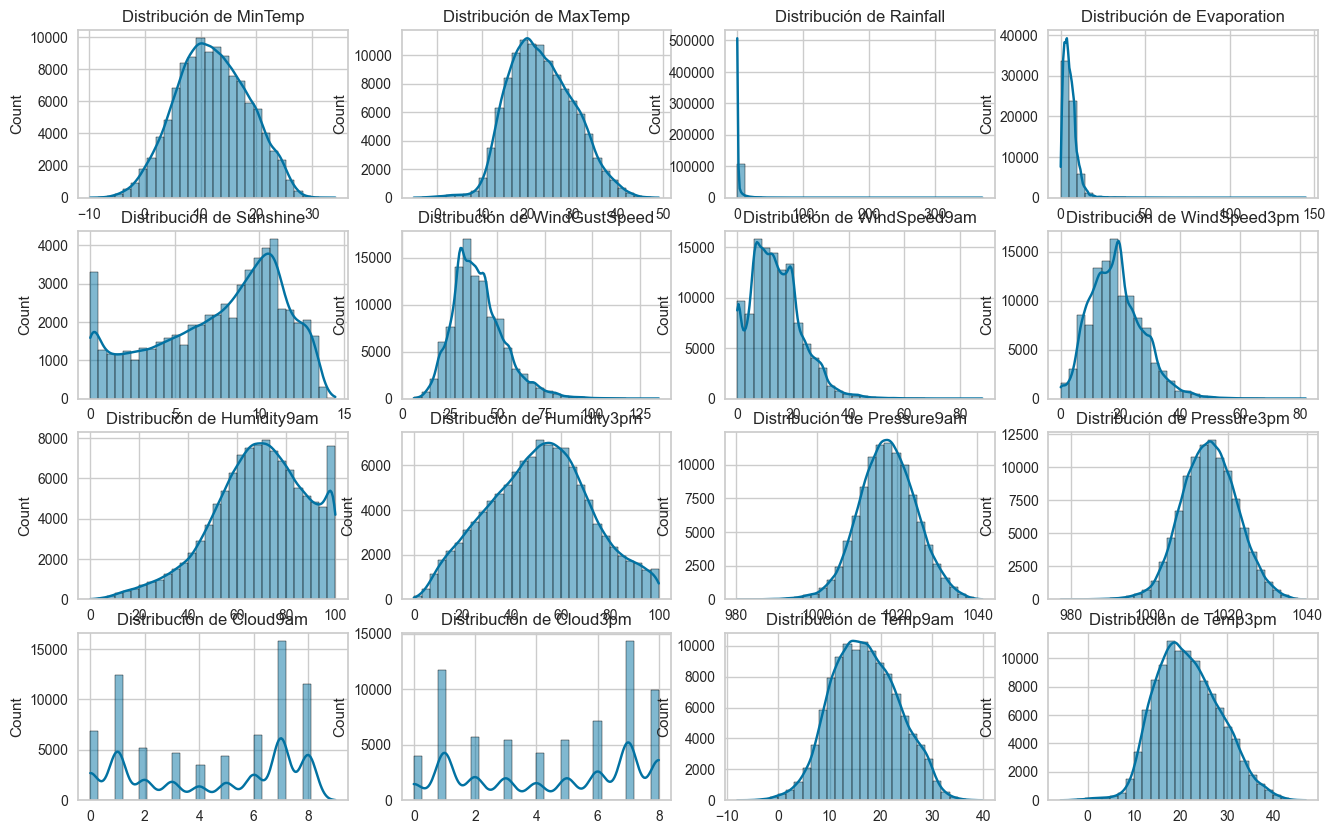

In [397]:
plt.figure(figsize=(16, 10))
for i, var in enumerate(columnas_numericas, 1):
    plt.subplot(4, 4, i)
    sns.histplot(df_train[var], kde=True, bins=30)
    plt.title(f"Distribución de {var}")
    plt.xlabel("")

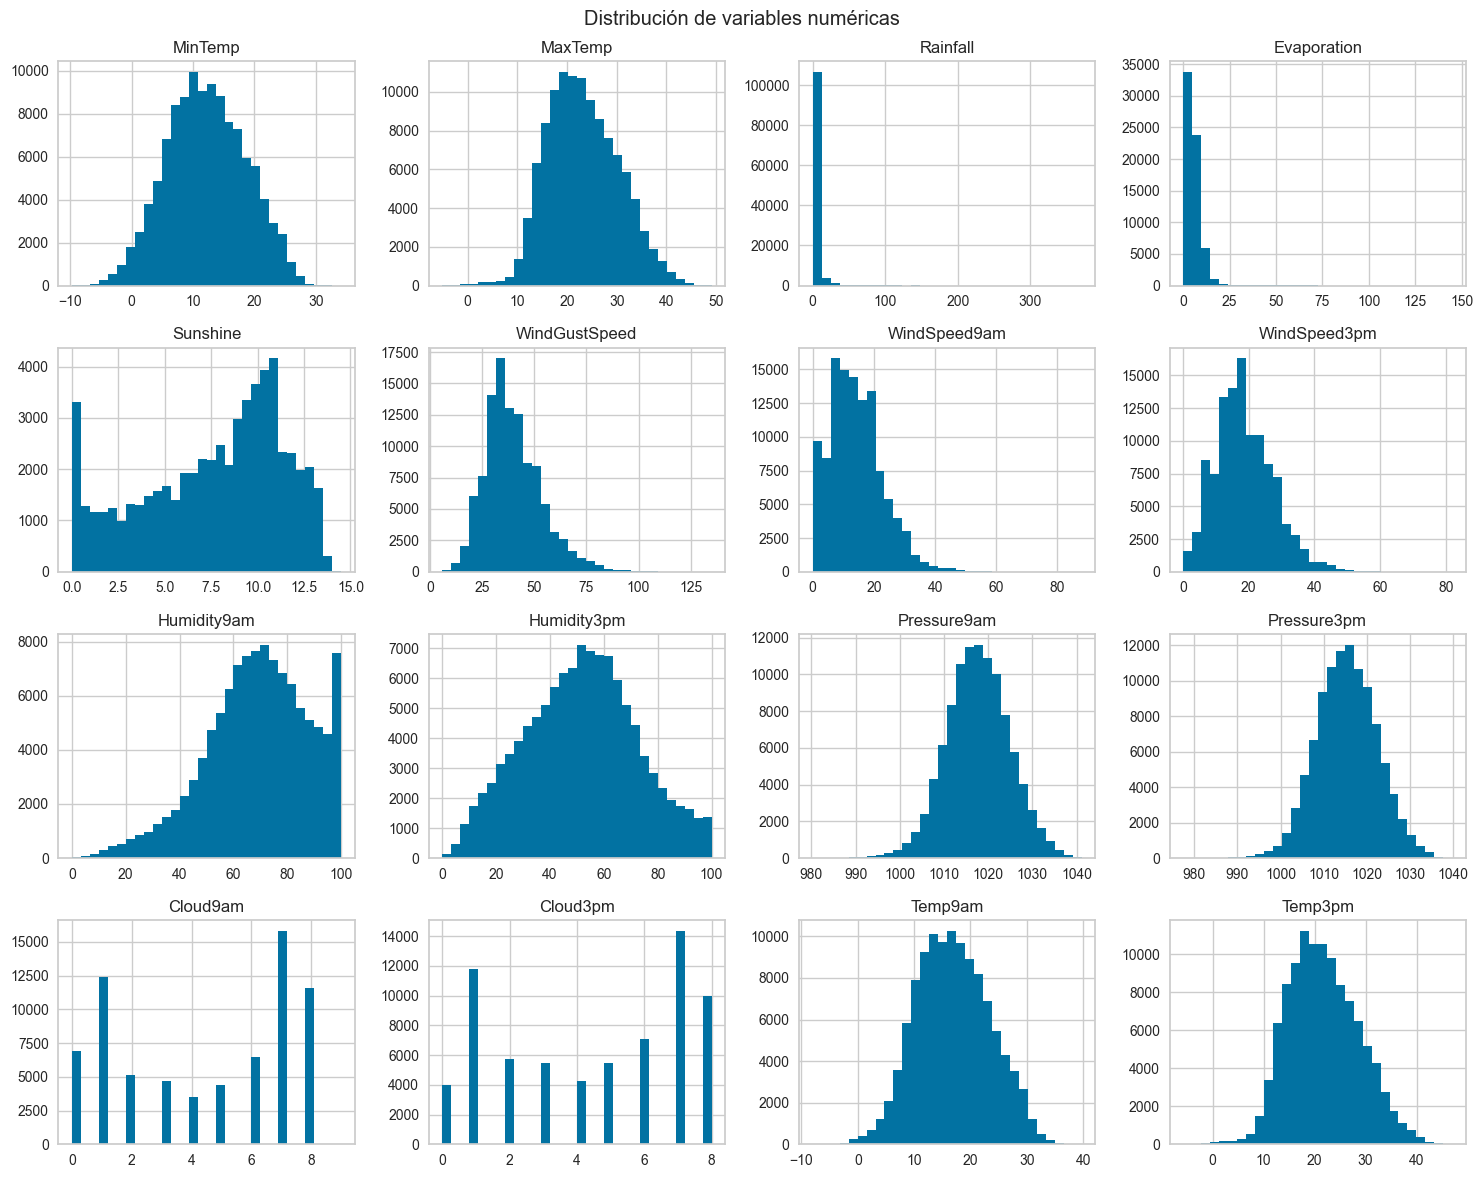

In [398]:
# graficamos histogramas para observar la distribución de las variables numéricas.
df_train[columnas_numericas].hist(figsize=(15, 12), bins=30)
plt.suptitle("Distribución de variables numéricas")
plt.tight_layout()
plt.show()

Graficamos histogramas de las variables numéricas para observar su distribución. Observamos que las variables no se encuentran en la misma escala, por ejemplo, temperatura, presión, humedad, velocidad del viento y lluvia tienen unidades y rangos distintos. Por este motivo, más adelante será necesario aplicar escalado

### Boxplots

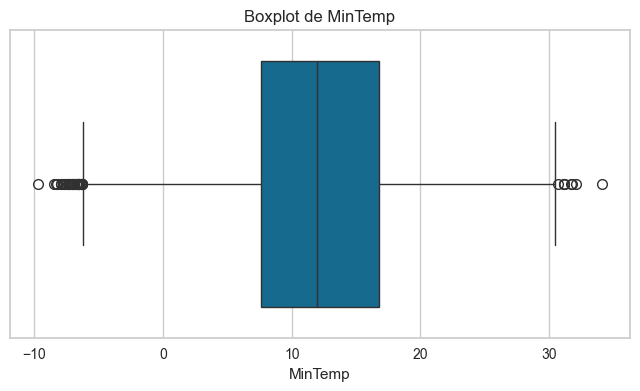

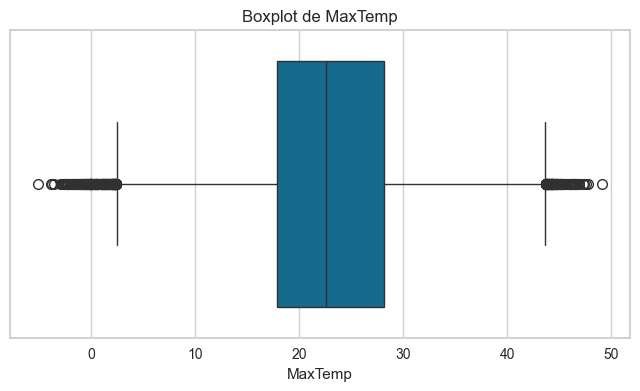

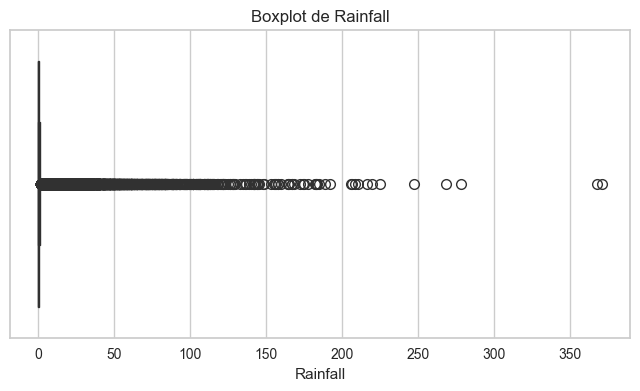

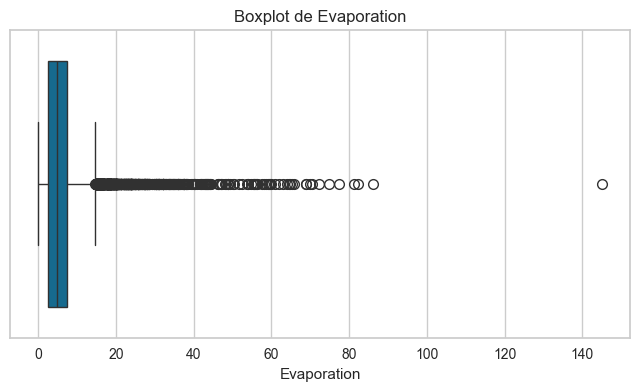

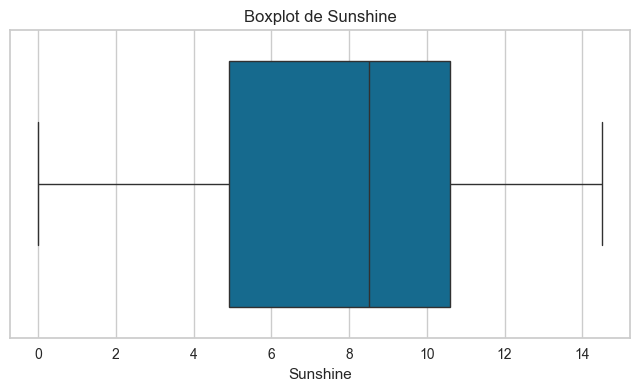

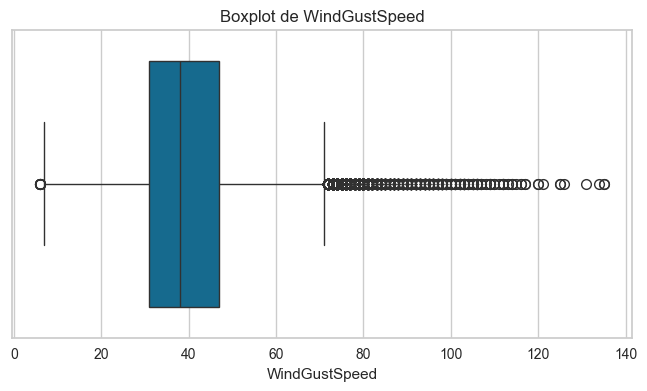

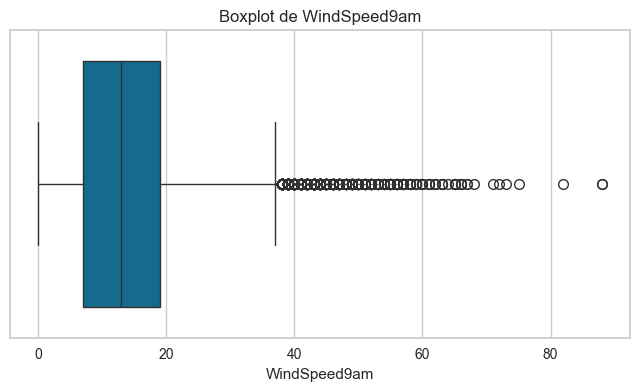

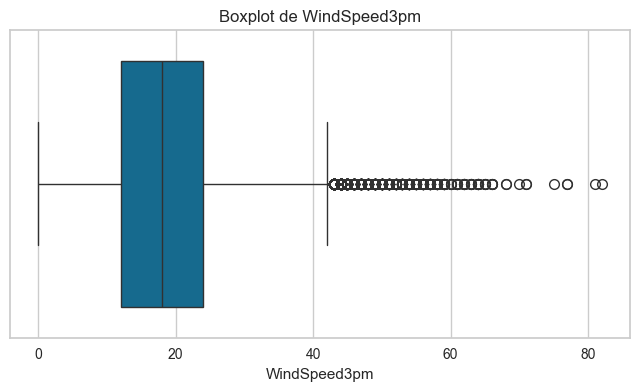

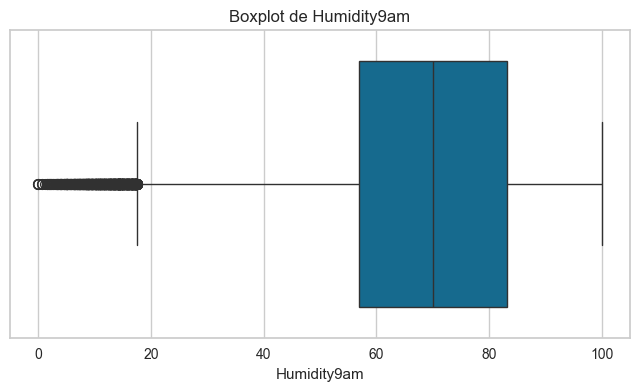

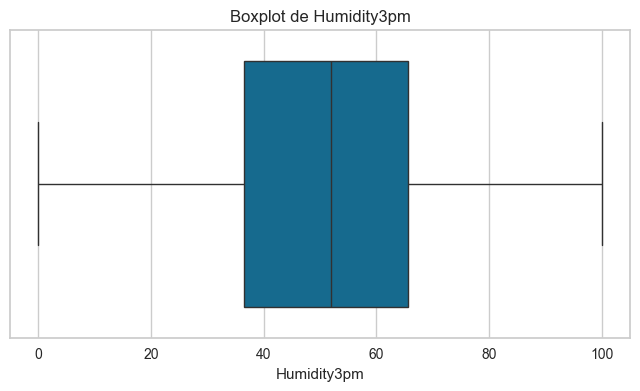

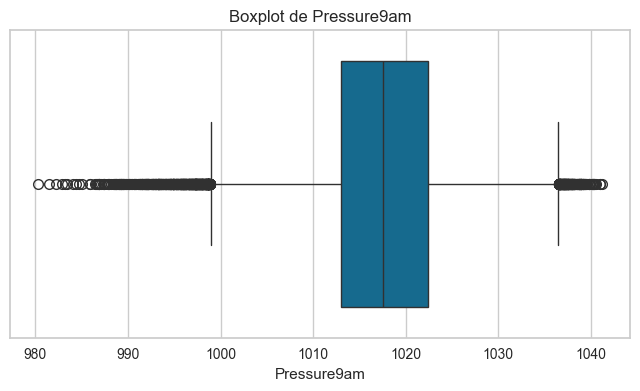

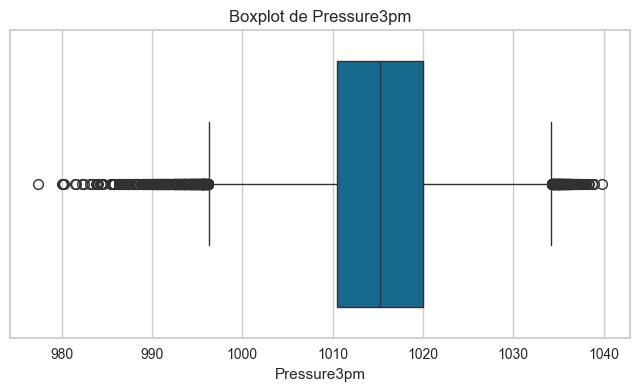

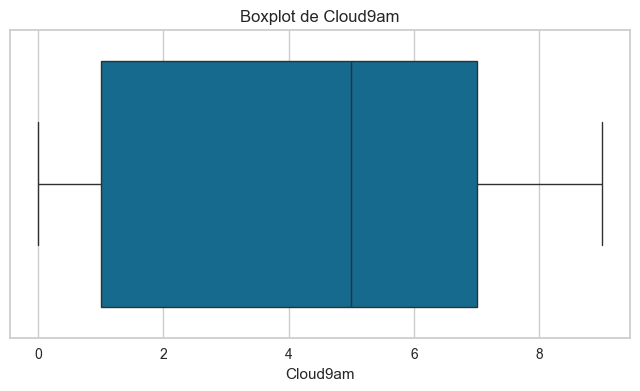

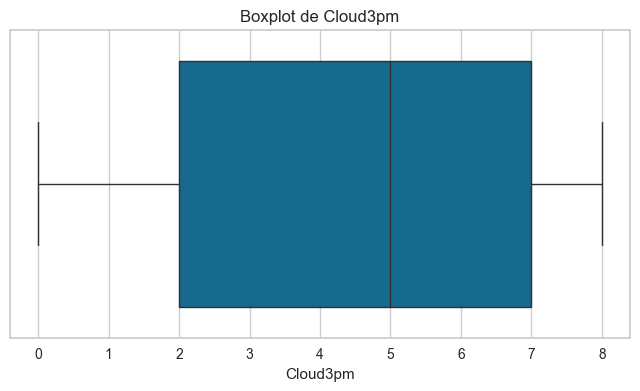

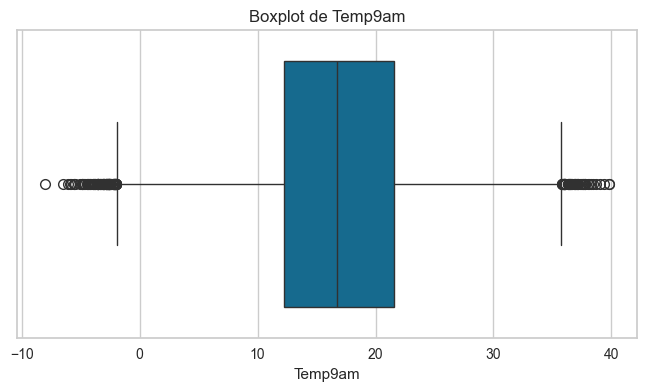

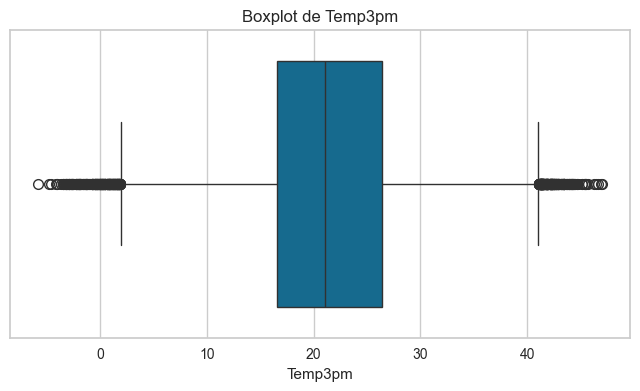

In [399]:
# Graficamos boxplots individuales para todas las variables numéricas.
for columna in columnas_numericas:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df_train, x=columna)
    plt.title(f"Boxplot de {columna}")
    plt.xlabel(columna)
    plt.show()

In [400]:
# calculamos outliers por variable numérica usando el criterio del rango intercuartílico
resumen_outliers = []

for columna in columnas_numericas:
    q1 = df_train[columna].quantile(0.25)
    q3 = df_train[columna].quantile(0.75)
    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    cantidad_outliers = ((df_train[columna] < limite_inferior) | (df_train[columna] > limite_superior)).sum()

    porcentaje_outliers = cantidad_outliers / df_train[columna].notna().sum() * 100

    resumen_outliers.append({
        "variable": columna,
        "limite_inferior": limite_inferior,
        "limite_superior": limite_superior,
        "cantidad_outliers": cantidad_outliers,
        "porcentaje_outliers": porcentaje_outliers
    })

resumen_outliers = pd.DataFrame(resumen_outliers)
resumen_outliers.sort_values(by="porcentaje_outliers", ascending=False)

,variable,limite_inferior,limite_superior,cantidad_outliers,porcentaje_outliers
2,Rainfall,-0.90,1.50,22829,20.277664
5,WindGustSpeed,7.00,71.00,2874,2.702957
3,Evaporation,-4.60,14.60,1555,2.392013
6,WindSpeed9am,-11.00,37.00,1497,1.329001
7,WindSpeed3pm,-6.00,42.00,1308,1.172180
8,Humidity9am,17.60,122.40,1147,1.021417
10,Pressure9am,998.90,1036.50,1029,1.004579
11,Pressure3pm,996.25,1034.25,810,0.790645
15,Temp3pm,1.90,41.10,595,0.533556
1,MaxTemp,2.45,43.65,393,0.346347


In [401]:
# verificamos si existen valores negativos en variables que no deberían ser negativas
variables_no_negativas = ["Rainfall", "Evaporation", "Sunshine","WindGustSpeed", "WindSpeed9am", "WindSpeed3pm","Humidity9am", "Humidity3pm","Pressure9am", "Pressure3pm", "Cloud9am", "Cloud3pm"]

valores_negativos = {}

for columna in variables_no_negativas:
    cantidad_negativos = (df_train[columna] < 0).sum()
    valores_negativos[columna] = cantidad_negativos

pd.Series(valores_negativos).sort_values(ascending=False)

Rainfall         0
Evaporation      0
Sunshine         0
WindGustSpeed    0
WindSpeed9am     0
WindSpeed3pm     0
Humidity9am      0
Humidity3pm      0
Pressure9am      0
Pressure3pm      0
Cloud9am         0
Cloud3pm         0
dtype: int64

In [402]:
# observamos los valores más frecuentes de Rainfall
df_train["Rainfall"].value_counts().head(20)

Rainfall
0.0    72226
0.2     6959
0.4     3000
0.6     2062
0.8     1616
1.0     1378
1.2     1181
1.4     1089
1.6      954
1.8      871
2.0      832
2.2      772
2.4      677
2.6      665
2.8      590
3.0      557
3.2      537
3.4      472
3.8      467
3.6      447
Name: count, dtype: int64

Analizamos posibles valores extremos utilizando el criterio del rango intercuartílico (IQR). Este criterio marca como posibles outliers los valores menores a Q1 - 1.5 * IQR o mayores a Q3 + 1.5 * IQR. Observamos también que una gran parte de las observaciones tiene lluvia igual o cercana a 0 mm. Esto hace que el rango intercuartílico sea bajo y que valores de lluvia mayores a 2 mm sean marcados como outliers. Estos valores no necesariamente representan errores, sino que pueden ser días con mayor cantidad de lluvia.

### Matriz de correlación

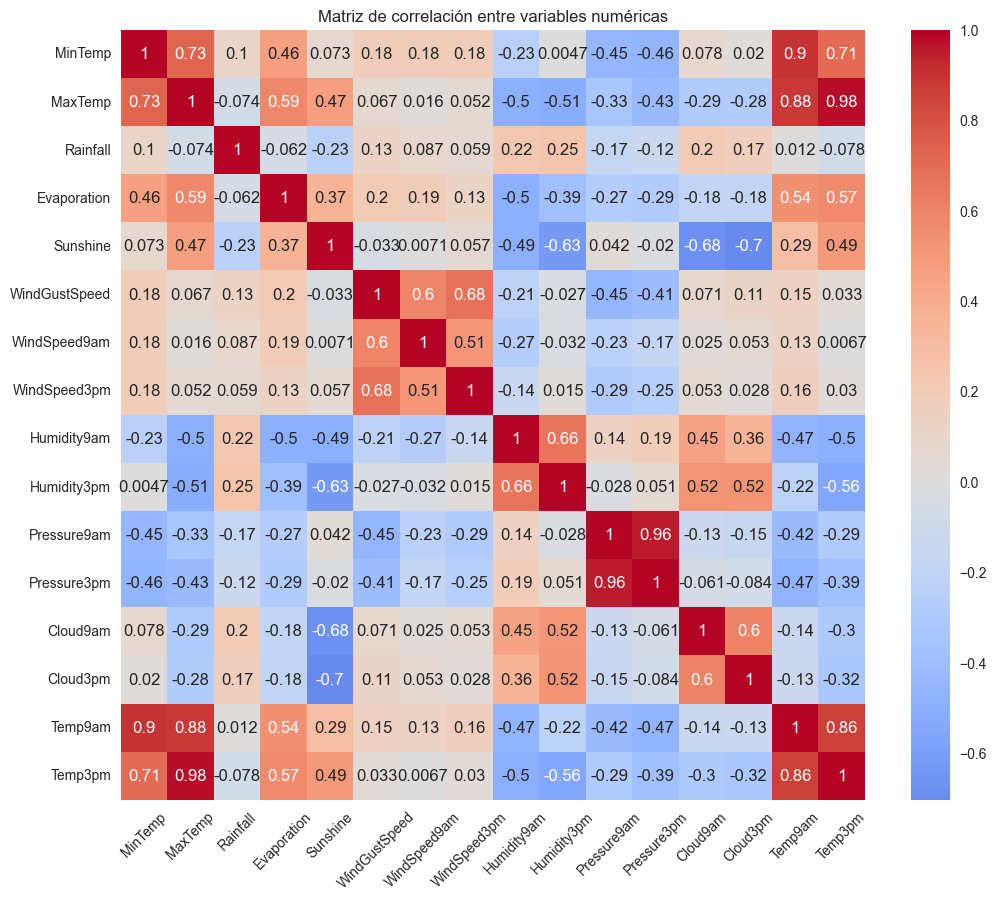

In [403]:
# calculamos la matriz de correlación entre variables numéricas
correlacion = df_train[columnas_numericas].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlacion, cmap="coolwarm", center=0, annot=True)
plt.title("Matriz de correlación entre variables numéricas")
plt.xticks(rotation=45)
plt.show()

Se identifican correlaciones positivas fuertes entre variables relacionadas con la temperatura, como "MaxTemp" y "Temp3pm", y entre variables de presión, como "Pressure9am" y "Pressure3pm", también se observan correlaciones negativas entre "Sunshine" y variables como "Cloud9am", "Cloud3pm" y "Humidity3pm", lo cual es coherente con el clima, a mayor nubosidad o humedad o menor cantidad de horas de sol.
Esta matriz se utiliza como análisis exploratorio. No se eliminan variables automáticamente por correlación en esta etapa

In [404]:
df_train[columnas_categoricas].nunique()

Date            3409
WindGustDir       16
WindDir9am        16
WindDir3pm        16
RainToday          2
Region            10
RainTomorrow       2
dtype: int64

In [405]:
# convertimos Date a formato fecha y extraemos el mes como variable numérica
df_train["Date"] = pd.to_datetime(df_train["Date"])
df_train["Month"] = df_train["Date"].dt.month

df_train = df_train.drop(columns=["Date"])

df_test["Date"] = pd.to_datetime(df_test["Date"])
df_test["Month"] = df_test["Date"].dt.month
# eliminamos la columna Date original para evitar codificar fechas completas

df_test = df_test.drop(columns=["Date"])

Cambiamos la variable mes por Season para bajar las opciones de la variable de 12 a 4 y bajar la dimensionalidad del modelo

In [406]:
def asignar_estacion(mes):
    if mes in [12, 1, 2]:
        return 'Summer'
    elif mes in [3, 4, 5]:
        return 'Autumn'
    elif mes in [6, 7, 8]:
        return 'Winter'
    else:
        return 'Spring'

df_train['Season'] = df_train['Month'].apply(asignar_estacion)
# Eliminamos la variable original
df_train.drop('Month', axis=1, inplace = True)
df_test['Season'] = df_test['Month'].apply(asignar_estacion)
# Eliminamos la variable original
df_test.drop('Month', axis=1, inplace = True)

In [407]:
X_train = df_train.drop(columns=["RainTomorrow"])
X_test = df_test.drop(columns=["RainTomorrow"])

y_train = df_train["RainTomorrow"]
y_test = df_test["RainTomorrow"]

Vemos que Location tiene demasiadas categorias en comparacion con las demas porque son ciudades, podemos reducirla agrupando por regiones mas grandes en vez de por ciudad

La columna "Date" se convierte a formato fecha y se utiliza para extraer el mes de la observación, lo que permite conservar información  sobre estaciones, ya que la probabilidad de lluvia puede variar según la época del año. Luego se elimina la fecha completa, porque codificar cada día como una categoría distinta generaría muchas columnas y no aportaría una representación simple para el modelo.

In [408]:
# codificamos la variable objetivo: No = 0, Yes = 1.
y_train = y_train.map({"No": 0, "Yes": 1})
y_test = y_test.map({"No": 0, "Yes": 1})

In [409]:
y = pd.concat([y_train, y_test])

La variable objetivo se codifica como variable binaria donde "No" se representa con 0 y "Yes" con 1 para que la clase positiva corresponda a los días en los que si llueve

In [410]:
# ahora identificamos variables numéricas y categóricas dentro de X
columnas_numericas = X_train.select_dtypes(include=["int64", "float64"]).columns
columnas_categoricas = X_train.select_dtypes(include=["object"]).columns

print("Variables numéricas:")
print(columnas_numericas)

print("\nVariables categóricas:")
print(columnas_categoricas)

Variables numéricas:
Index(['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
       'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
       'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm',
       'Temp9am', 'Temp3pm'],
      dtype='object')

Variables categóricas:
Index(['WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday', 'Season'], dtype='object')


Se vuelven a identificar las columnas numéricas y categóricas únicamente dentro de "X" para no incluir la variable objetivo dentro de las predictoras

In [411]:
# verificamos que train y test mantengan proporciones similares de clases
print("Proporción total:")
print(y.value_counts(normalize=True))

print("\nProporción en entrenamiento:")
print(y_train.value_counts(normalize=True))

print("\nProporción en prueba:")
print(y_test.value_counts(normalize=True))

Proporción total:
RainTomorrow
0    0.775791
1    0.224209
Name: proportion, dtype: float64

Proporción en entrenamiento:
RainTomorrow
0    0.775787
1    0.224213
Name: proportion, dtype: float64

Proporción en prueba:
RainTomorrow
0    0.775808
1    0.224192
Name: proportion, dtype: float64


Se divide el dataset en conjuntos de entrenamiento y prueba. Usamos un 20% de los datos para prueba y se mantiene la proporción de clases mediante "stratify=y", ya que la variable objetivo está desbalanceada

In [412]:
# definimos el preprocesamiento para variables numéricas
preprocesamiento_numerico = Pipeline(steps=[
    #("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# definimos el preprocesamiento para variables categóricas
preprocesamiento_categorico = Pipeline(steps=[
   # ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# combinamos ambos preprocesamientos
preprocesamiento = ColumnTransformer(transformers=[
    ("num", preprocesamiento_numerico, columnas_numericas),
    ("cat", preprocesamiento_categorico, columnas_categoricas)
])

### Imputacion de Datos


#### Variables Numericas

En primer lugar, imputaremos los datos faltantes de las variables numéricas. Tras observar las distribuciones de las variables en el análisis descriptivo previo, decidimos realizar dos imputaciones.

*   Por un lado, en las variables con distribución cercana a la normal, optamos por imputar calculando la mediana por región y estación. Optamos por la mediana debido a su robustez frente a valores atípicos. A su vez, la decisión de calcularla por región y estacion fue tomada buscando preservar patrones locales relevantes y las diferencias climaticas que pueden darse en cada estacion que pueden ser distintas por region, que podrían verse sesgados si se empleara una mediana global.
*   Por otro lado, realizamos imputaciones con KNN por región en variables con varias modas o distribuciones sesgadas. Debido al alto coste computacional de este método, lo realizamos únicamente en las variables en las que lo creímos estrictamente necesario, como 'Evaporation', 'Cloud9am', 'Cloud3pm'.

In [413]:
df_train.isnull().sum()

MinTemp            512
MaxTemp            252
Rainfall          1140
Evaporation      48714
Sunshine         54326
WindGustDir       7443
WindGustSpeed     7394
WindDir9am        8058
WindDir3pm        3073
WindSpeed9am      1081
WindSpeed3pm      2135
Humidity9am       1427
Humidity3pm       2916
Pressure9am      11291
Pressure3pm      11274
Cloud9am         42889
Cloud3pm         45699
Temp9am            727
Temp3pm           2206
RainToday         1140
Region               0
RainTomorrow         0
Season               0
dtype: int64

In [414]:
variables_mediana = ['MinTemp', 'MaxTemp', 'Rainfall', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Temp9am', 'Temp3pm']
len(variables_mediana)

13

In [415]:
df_train.head()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,...,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,Region,RainTomorrow,Season
63909,11.9,25.4,0.0,NaN,NaN,WSW,78.0,W,NW,32.0,...,1015.6,1012.5,4.0,NaN,16.0,24.4,No,5,No,Spring
87162,14.2,22.9,24.8,4.2,3.8,SE,36.0,SW,SSE,7.0,...,1025.2,1021.7,6.0,7.0,17.9,21.7,Yes,6,No,Winter
90232,19.1,27.9,0.0,NaN,NaN,ESE,41.0,S,SE,24.0,...,1018.5,1015.9,NaN,NaN,23.8,25.6,No,6,No,Summer
88210,20.6,30.5,0.0,7.0,8.5,E,31.0,SSE,E,16.0,...,1012.5,1010.0,7.0,8.0,26.5,27.6,No,3,No,Spring
71438,21.5,37.5,0.0,12.0,6.7,NW,41.0,NW,WSW,11.0,...,1013.0,1011.9,7.0,7.0,28.8,35.1,No,0,No,Summer


In [416]:
# Aca solo usamos Xtrain para calcular las mediasnas para no tener fuga de datos, pero imputamos tanto en train como en test para no tener nulos en ningun conjunto.
for df2 in [X_train, X_test]:
  for variable in variables_mediana:
    mediana_region = X_train.groupby(['Region','Season'])[variable].median()
    df2[variable] = df2.apply(
      lambda row: mediana_region.loc[(row["Region"], row["Season"])] if pd.isnull(row[variable]) else row[variable],
      axis=1
    )

In [417]:
X_train.isnull().sum()


MinTemp              0
MaxTemp              0
Rainfall             0
Evaporation      48714
Sunshine             0
WindGustDir       7443
WindGustSpeed        0
WindDir9am        8058
WindDir3pm        3073
WindSpeed9am         0
WindSpeed3pm         0
Humidity9am          0
Humidity3pm          0
Pressure9am          0
Pressure3pm          0
Cloud9am         42889
Cloud3pm         45699
Temp9am              0
Temp3pm              0
RainToday         1140
Region               0
Season               0
dtype: int64

In [418]:
X_test.isnull().sum()

MinTemp              0
MaxTemp              0
Rainfall             0
Evaporation      12098
Sunshine             0
WindGustDir       1885
WindGustSpeed        0
WindDir9am        1951
WindDir3pm         703
WindSpeed9am         0
WindSpeed3pm         0
Humidity9am          0
Humidity3pm          0
Pressure9am          0
Pressure3pm          0
Cloud9am         10752
Cloud3pm         11377
Temp9am              0
Temp3pm              0
RainToday          266
Region               0
Season               0
dtype: int64

#### KNN Imputer

##### Escalado de Datos


Ya que KNN es un método basado en distancias, es necesario escalar los datos antes de utilizarlo para imputar. Sino las variables con valores grandes podrían dominar la distancia y afectar la imputacion

In [419]:
scaler = StandardScaler().set_output(transform="pandas")
X_train[columnas_numericas] = scaler.fit_transform(X_train[columnas_numericas])
X_test[columnas_numericas] = scaler.transform(X_test[columnas_numericas])

##### KNN

In [420]:
# Variables a imputar con KNN por región
variables_knn = ['Evaporation', 'Cloud9am', 'Cloud3pm']

In [421]:
for (region, season), train_grupo in X_train.groupby(["Region", "Season"]):
    # Obtenemos la misma zona y estacion para test
    test_grupo = X_test[
        (X_test["Region"] == region) &
        (X_test["Season"] == season)
    ]
    imputer = KNNImputer(n_neighbors=5)
    # Ajustar solo con train para evitar fuga de datos
    train_imputed = imputer.fit_transform(train_grupo[variables_knn])
    X_train.loc[train_grupo.index, variables_knn] = train_imputed
    if len(test_grupo) > 0:
        test_imputed = imputer.transform(test_grupo[variables_knn])
        X_test.loc[test_grupo.index, variables_knn] = test_imputed

In [422]:
X_train.isnull().sum()

MinTemp             0
MaxTemp             0
Rainfall            0
Evaporation         0
Sunshine            0
WindGustDir      7443
WindGustSpeed       0
WindDir9am       8058
WindDir3pm       3073
WindSpeed9am        0
WindSpeed3pm        0
Humidity9am         0
Humidity3pm         0
Pressure9am         0
Pressure3pm         0
Cloud9am            0
Cloud3pm            0
Temp9am             0
Temp3pm             0
RainToday        1140
Region              0
Season              0
dtype: int64

In [423]:
X_train.head()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,Region,Season
63909,-0.043450,0.306861,-0.273691,-0.471938,-0.213143,WSW,2.888202,W,NW,2.029317,...,-0.504503,-0.316714,-0.423987,-0.152137,-0.479947,-0.148366,0.387624,No,5,Spring
87162,0.314692,-0.043913,2.627483,-0.300905,-1.393811,SE,-0.291078,SW,SSE,-0.789026,...,0.455770,1.094236,0.941231,0.540361,0.917059,0.143495,-0.001618,Yes,6,Winter
90232,1.077690,0.657634,-0.273691,0.585477,0.606766,ESE,0.087408,S,SE,1.127447,...,0.121130,0.109511,0.080550,0.039760,0.009487,1.049801,0.560621,No,6,Summer
88210,1.311260,1.022439,-0.273691,0.364224,0.147617,E,-0.669564,SSE,E,0.225577,...,0.237526,-0.772333,-0.794970,0.886611,1.284692,1.464551,0.848948,No,3,Spring
71438,1.451403,2.004605,-0.273691,1.551955,-0.442717,NW,0.087408,NW,WSW,-0.338091,...,-1.474476,-0.698846,-0.513023,0.886611,0.917059,1.817856,1.930176,No,0,Summer


In [424]:
X_train87 = X_train.copy()

In [425]:
X_train.head()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,Region,Season
63909,-0.043450,0.306861,-0.273691,-0.471938,-0.213143,WSW,2.888202,W,NW,2.029317,...,-0.504503,-0.316714,-0.423987,-0.152137,-0.479947,-0.148366,0.387624,No,5,Spring
87162,0.314692,-0.043913,2.627483,-0.300905,-1.393811,SE,-0.291078,SW,SSE,-0.789026,...,0.455770,1.094236,0.941231,0.540361,0.917059,0.143495,-0.001618,Yes,6,Winter
90232,1.077690,0.657634,-0.273691,0.585477,0.606766,ESE,0.087408,S,SE,1.127447,...,0.121130,0.109511,0.080550,0.039760,0.009487,1.049801,0.560621,No,6,Summer
88210,1.311260,1.022439,-0.273691,0.364224,0.147617,E,-0.669564,SSE,E,0.225577,...,0.237526,-0.772333,-0.794970,0.886611,1.284692,1.464551,0.848948,No,3,Spring
71438,1.451403,2.004605,-0.273691,1.551955,-0.442717,NW,0.087408,NW,WSW,-0.338091,...,-1.474476,-0.698846,-0.513023,0.886611,0.917059,1.817856,1.930176,No,0,Summer


In [426]:
#Vuelvo a la escala original para poder comparar las distribuciones antes y después de imputar 
X_train_imp_values = scaler.inverse_transform(X_train[columnas_numericas])

X_train_imp = X_train.copy()
X_train_imp[columnas_numericas] = X_train_imp_values

In [427]:
X_train_imp.head()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,Region,Season
63909,11.9,25.4,0.0,3.48000,7.4,WSW,78.0,W,NW,32.0,...,41.1,1015.6,1012.5,4.000000,3.200000,16.0,24.4,No,5,Spring
87162,14.2,22.9,24.8,4.20000,3.8,SE,36.0,SW,SSE,7.0,...,60.9,1025.2,1021.7,6.000000,7.000000,17.9,21.7,Yes,6,Winter
90232,19.1,27.9,0.0,7.93141,9.9,ESE,41.0,S,SE,24.0,...,54.0,1018.5,1015.9,4.554217,4.531312,23.8,25.6,No,6,Summer
88210,20.6,30.5,0.0,7.00000,8.5,E,31.0,SSE,E,16.0,...,56.4,1012.5,1010.0,7.000000,8.000000,26.5,27.6,No,3,Spring
71438,21.5,37.5,0.0,12.00000,6.7,NW,41.0,NW,WSW,11.0,...,21.1,1013.0,1011.9,7.000000,7.000000,28.8,35.1,No,0,Summer


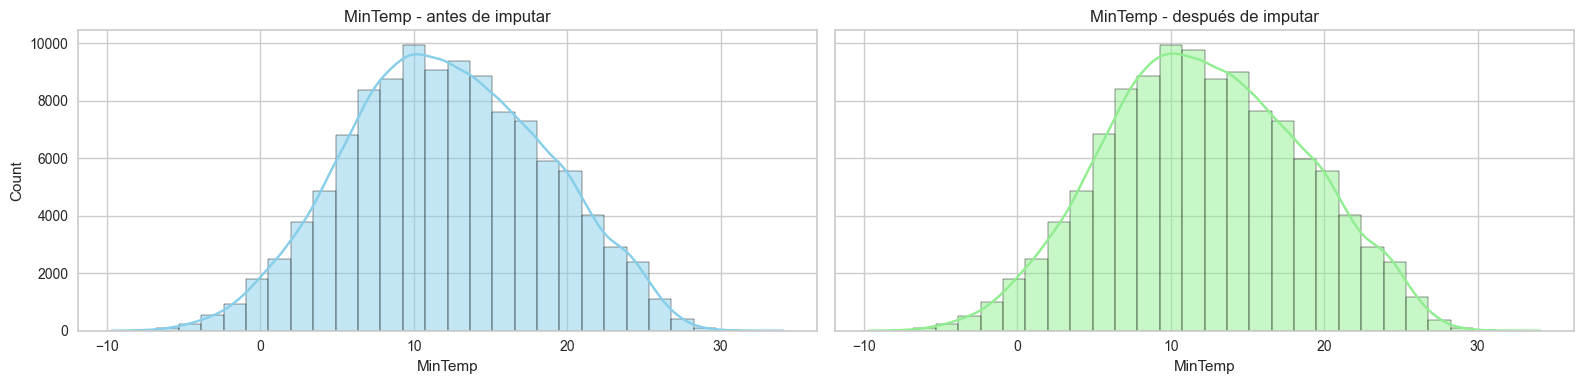

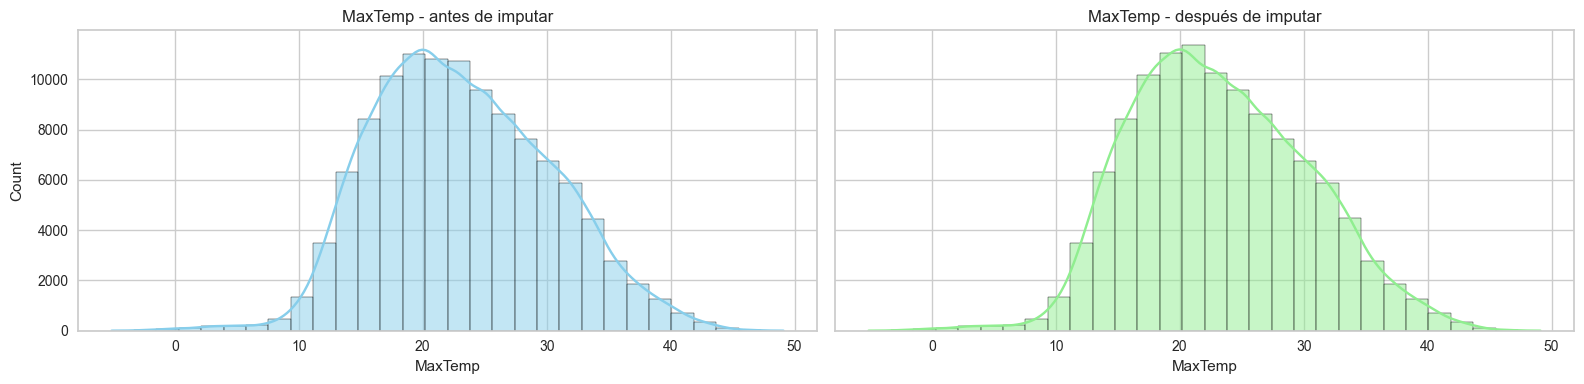

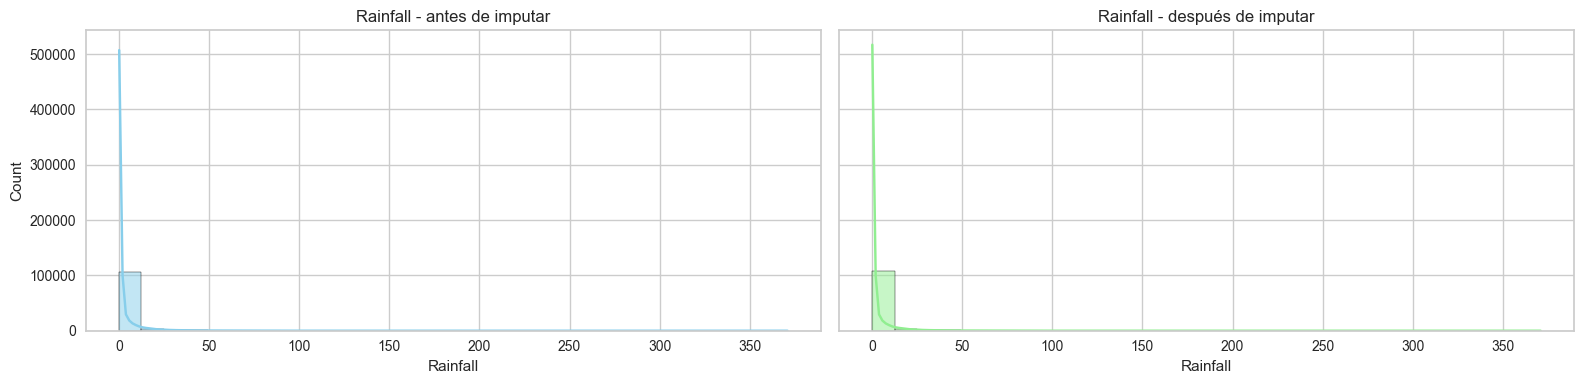

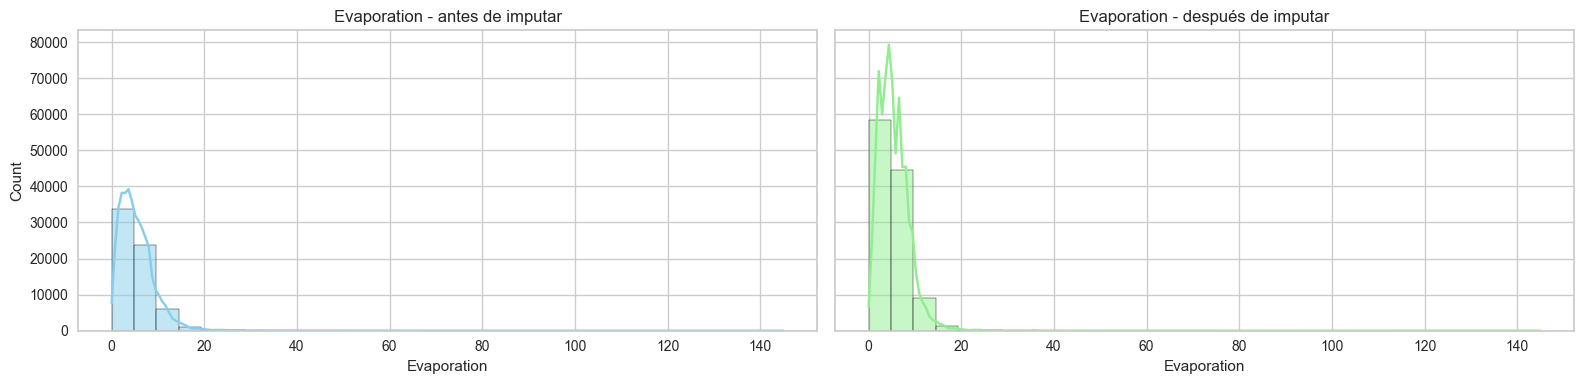

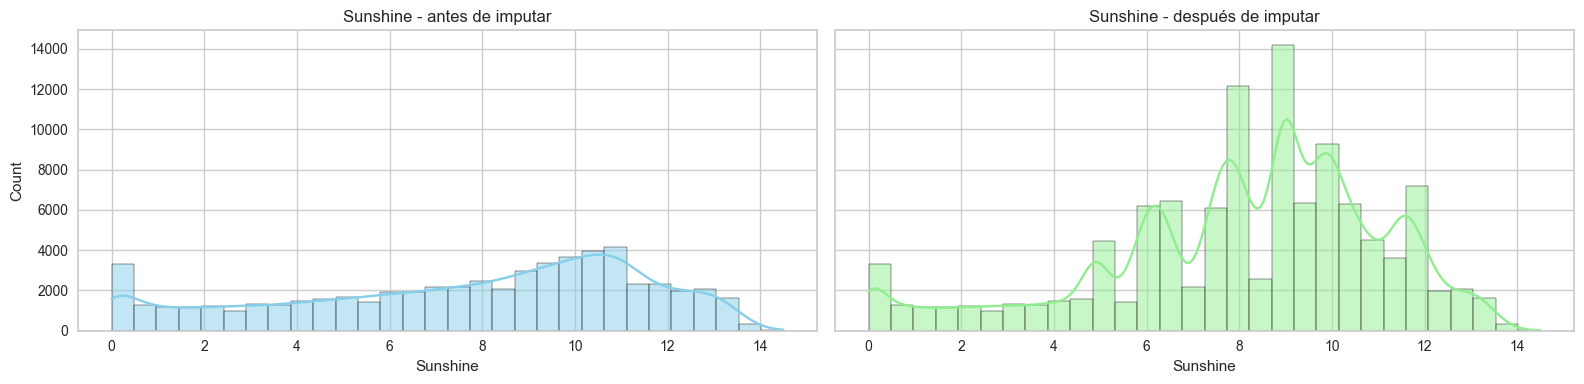

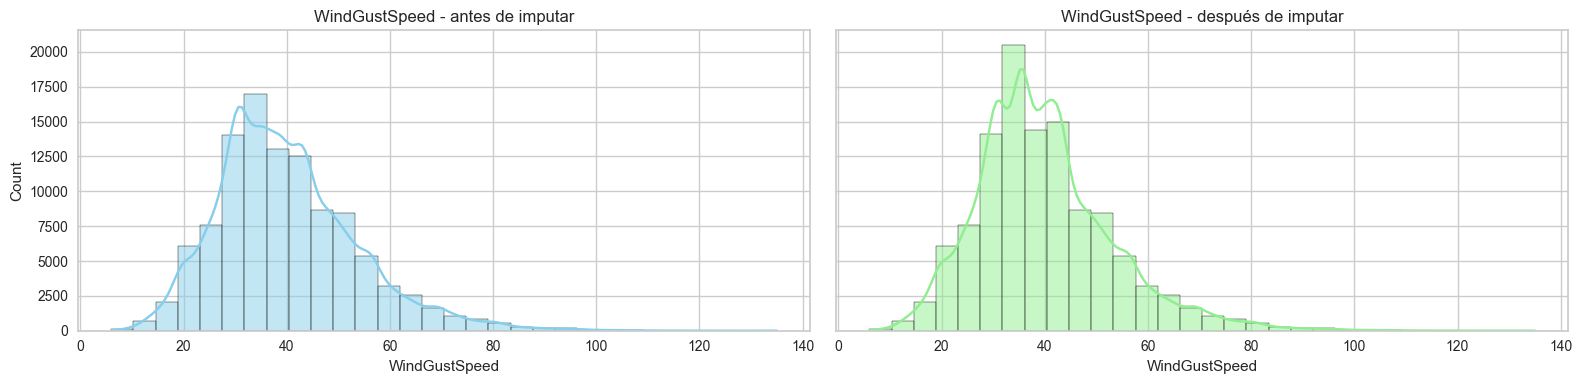

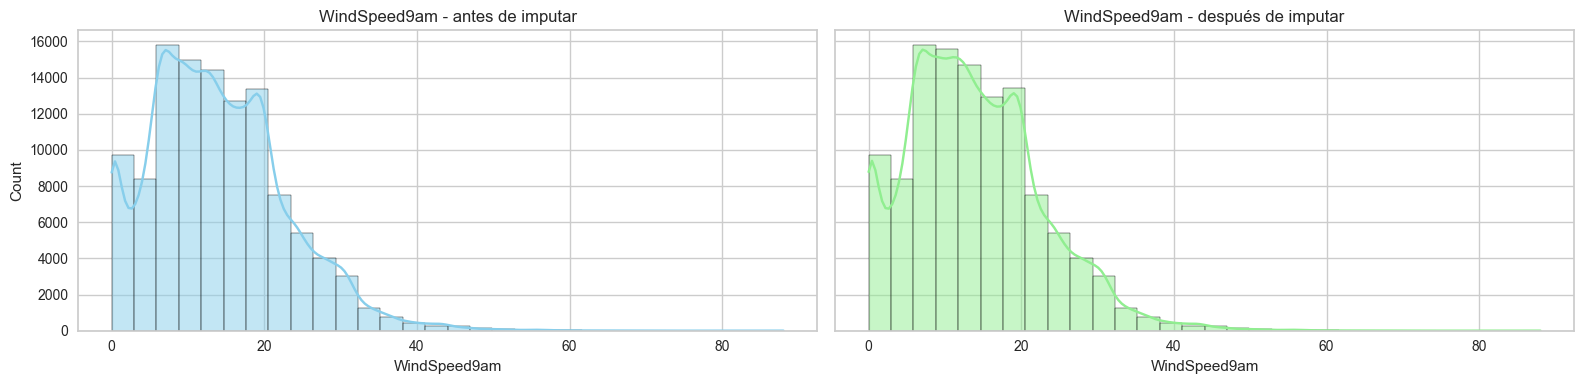

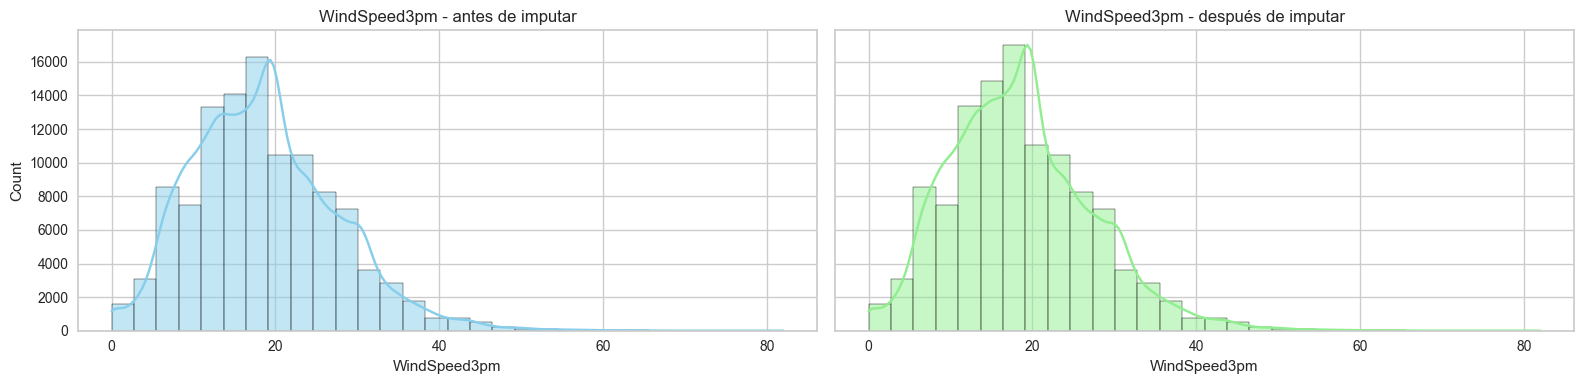

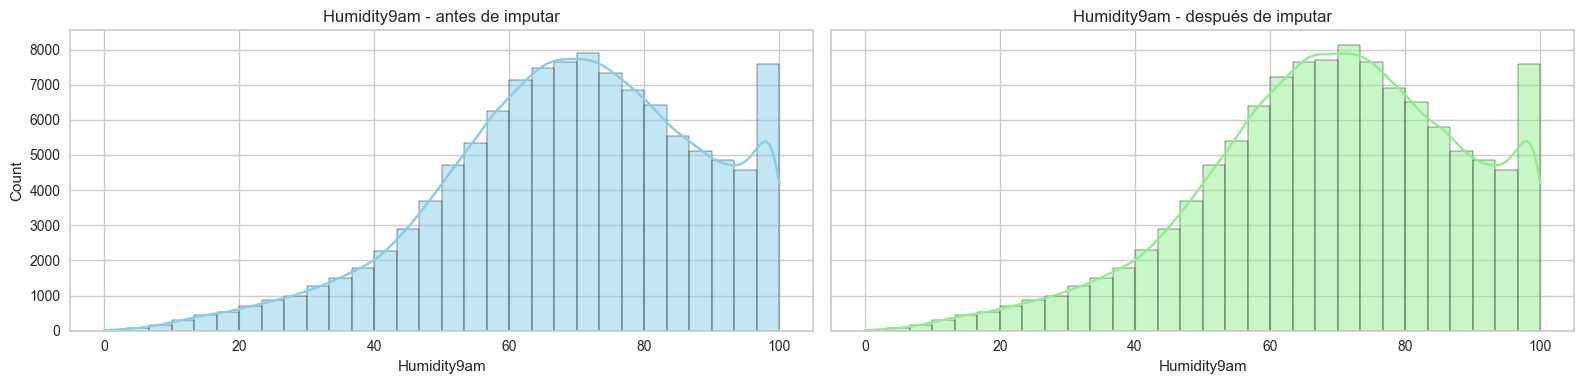

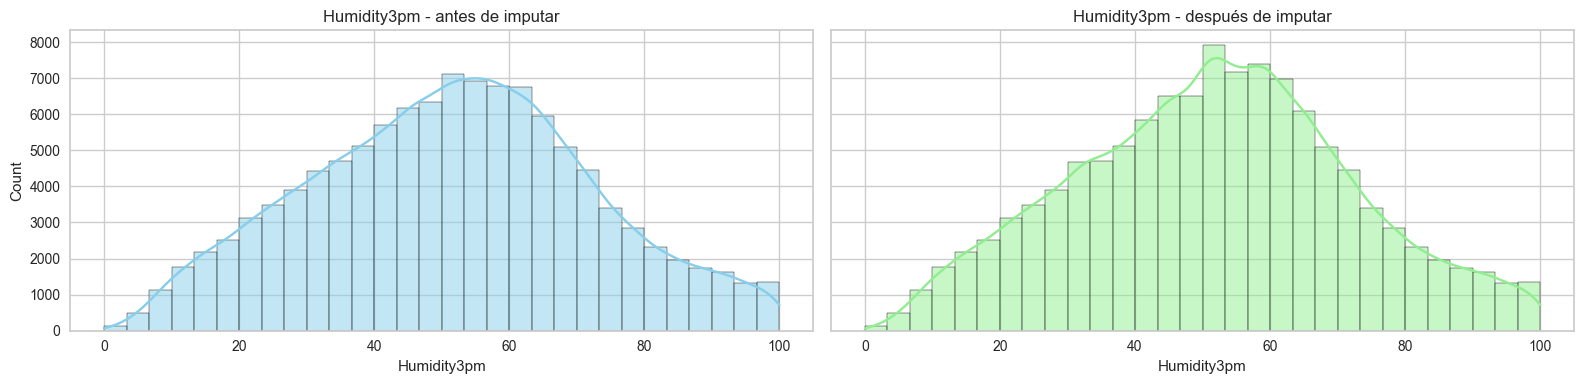

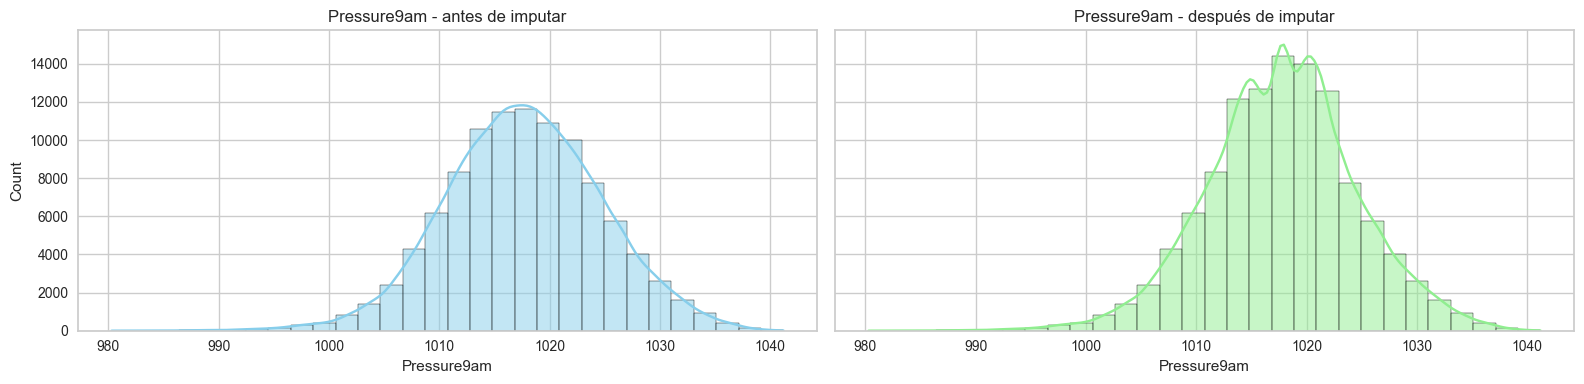

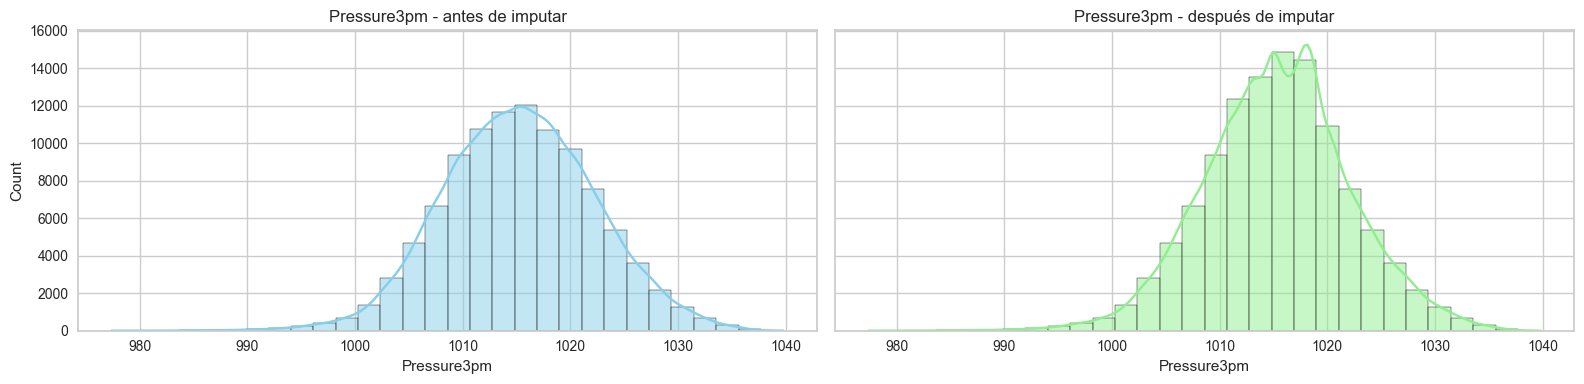

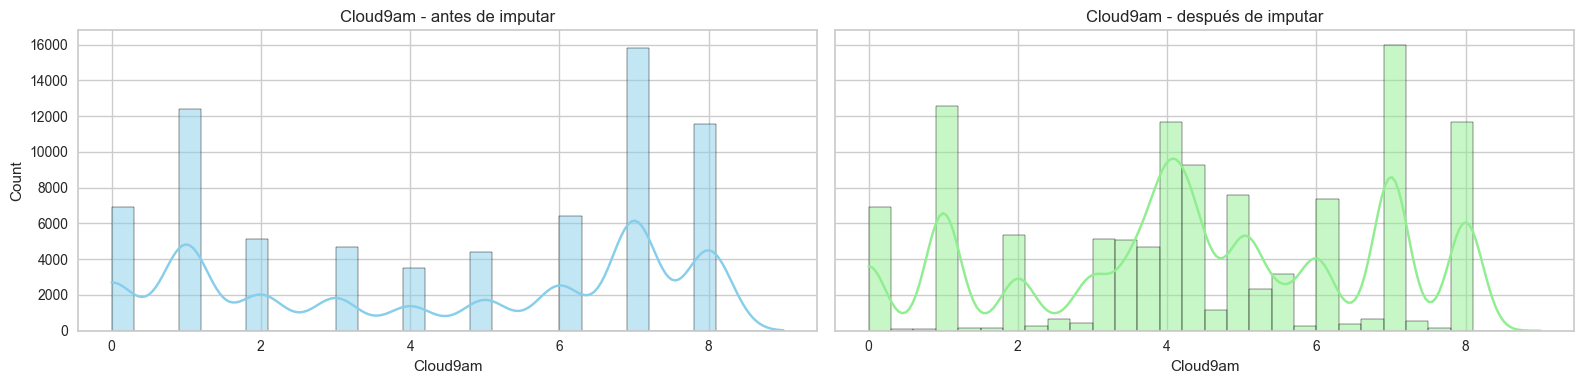

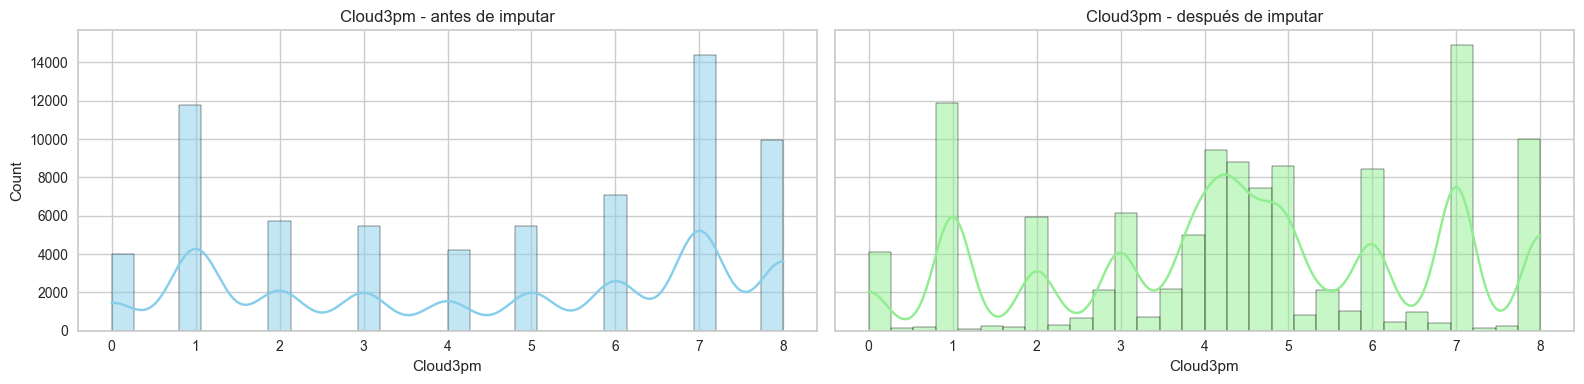

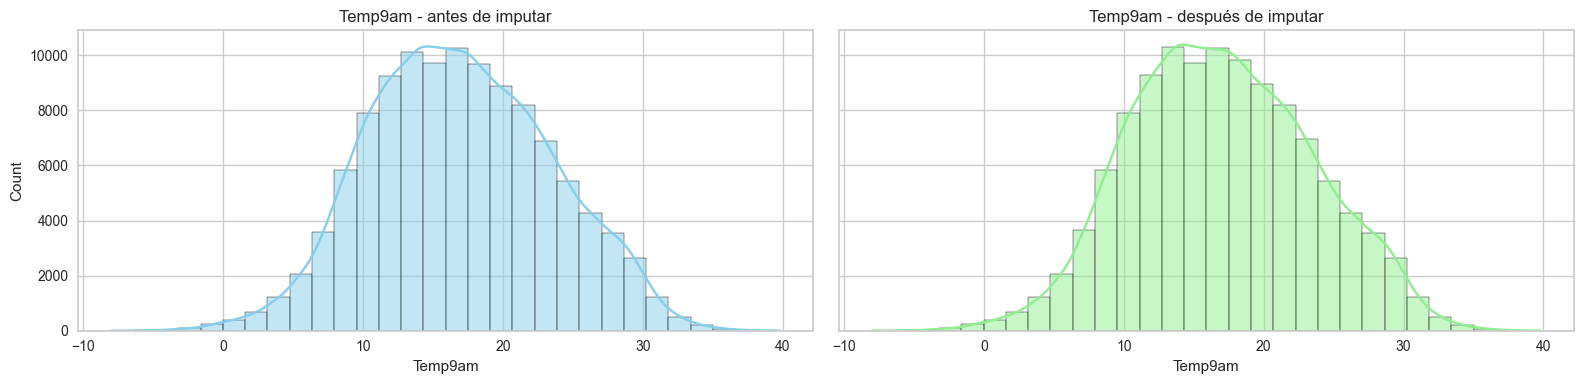

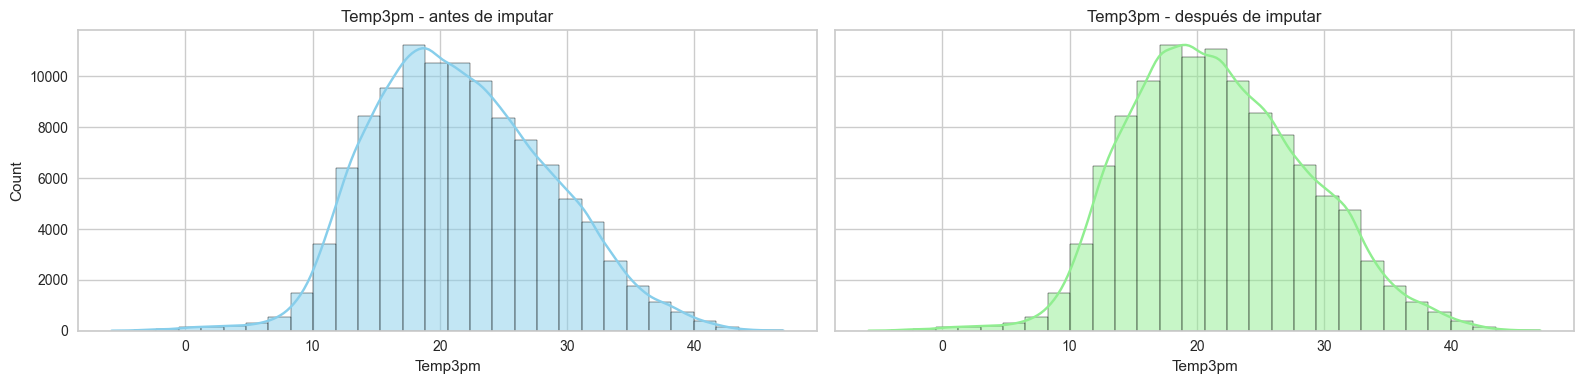

In [428]:
for var in columnas_numericas:
    fig, axes = plt.subplots(1, 2, figsize=(16, 4), sharey=True)
    # Antes de imputar
    sns.histplot(df_train[var], kde=True, bins=30, ax=axes[0], color='skyblue')
    axes[0].set_title(f'{var} - antes de imputar')
    # Después de imputar
    sns.histplot(X_train_imp[var], kde=True, bins=30, ax=axes[1], color='lightgreen')
    axes[1].set_title(f'{var} - después de imputar')

    plt.tight_layout()
    plt.show()

Separamos el preprocesamiento según tipo de variable. Para las numéricas usamos imputación con mediana y escalado estándar. Para las categóricas usamos imputación con la categoría más frecuente y codificación one-hot. Todo esto se coloca dentro de un Pipeline y un ColumnTransformer para que se ajuste solo con el conjunto de entrenamiento y así evitar fuga de datos.

#### Variables categoricas 

In [429]:
for df in [X_train, X_test]:
  for variable in ['WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday']:
    moda_region = X_train.groupby(['Region','Season'])[variable].agg(lambda x: x.mode().iloc[0])
    df[variable] = df.apply(
      lambda row: moda_region[row['Region'], row['Season']] if pd.isnull(row[variable]) else row[variable],
      axis=1
    )


In [430]:
print(X_train.isnull().sum())

MinTemp          0
MaxTemp          0
Rainfall         0
Evaporation      0
Sunshine         0
WindGustDir      0
WindGustSpeed    0
WindDir9am       0
WindDir3pm       0
WindSpeed9am     0
WindSpeed3pm     0
Humidity9am      0
Humidity3pm      0
Pressure9am      0
Pressure3pm      0
Cloud9am         0
Cloud3pm         0
Temp9am          0
Temp3pm          0
RainToday        0
Region           0
Season           0
dtype: int64


## Ítem 2: Regresión logística

In [431]:
round(y_train.value_counts(normalize=True) * 100, 2)
#round(y_test.value_counts(normalize=True) * 100, 2)

RainTomorrow
0    77.58
1    22.42
Name: proportion, dtype: float64

Como ya habiamos visto el dataset esta desbalanceado por lo que usaremos class_weight = balanced para pque asigne un peso mayor a la clase minoritaria

In [432]:
# creamos un Pipeline que combina el preprocesamiento y la regresión logística

modelo_logistico = Pipeline(steps=[
    ("preprocesamiento", preprocesamiento),
    ("clasificador", LogisticRegression(max_iter=1000, random_state=42,class_weight="balanced"))
])

In [433]:
# Dataframe con el que entrenaremos al modelo
X_train

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,Region,Season
63909,-0.043450,0.306861,-0.273691,-0.471938,-0.213143,WSW,2.888202,W,NW,2.029317,...,-0.504503,-0.316714,-0.423987,-0.152137,-0.479947,-0.148366,0.387624,No,5,Spring
87162,0.314692,-0.043913,2.627483,-0.300905,-1.393811,SE,-0.291078,SW,SSE,-0.789026,...,0.455770,1.094236,0.941231,0.540361,0.917059,0.143495,-0.001618,Yes,6,Winter
90232,1.077690,0.657634,-0.273691,0.585477,0.606766,ESE,0.087408,S,SE,1.127447,...,0.121130,0.109511,0.080550,0.039760,0.009487,1.049801,0.560621,No,6,Summer
88210,1.311260,1.022439,-0.273691,0.364224,0.147617,E,-0.669564,SSE,E,0.225577,...,0.237526,-0.772333,-0.794970,0.886611,1.284692,1.464551,0.848948,No,3,Spring
71438,1.451403,2.004605,-0.273691,1.551955,-0.442717,NW,0.087408,NW,WSW,-0.338091,...,-1.474476,-0.698846,-0.513023,0.886611,0.917059,1.817856,1.930176,No,0,Summer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83187,-0.090164,-0.787553,-0.273691,-0.871015,-2.508886,WNW,0.390196,NW,WNW,-0.563558,...,-0.349307,-1.712966,-1.744687,0.678861,0.696479,-0.547755,-1.371173,No,0,Autumn
142256,1.077690,1.289027,-0.273691,0.174188,0.836340,ESE,-1.123747,SE,NNW,-0.563558,...,0.397572,-0.478385,-0.780131,-1.190884,-1.288740,1.280217,1.180525,No,4,Winter
50274,-2.768441,-1.769720,-0.273691,-0.820304,-0.573902,N,-0.896655,E,N,-1.578162,...,0.315124,0.888472,0.407015,0.213883,0.152307,-3.066977,-1.717166,No,9,Winter
85277,1.030975,0.896160,-0.273691,0.744298,0.213210,E,-0.972352,S,ENE,-0.563558,...,0.547918,-0.052161,-0.186558,-0.152137,0.181793,1.218773,1.079610,No,6,Summer


In [434]:
# entrenamos el modelo utilizando el conjunto de entrenamiento
modelo_logistico.fit(X_train, y_train)

Pipeline(memory=None,
         steps=[('preprocesamiento',
                 ColumnTransformer(n_jobs=None, remainder='drop',
                                   sparse_threshold=0.3,
                                   transformer_weights=None,
                                   transformers=[('num',
                                                  Pipeline(memory=None,
                                                           steps=[('scaler',
                                                                   StandardScaler(copy=True,
                                                                                  with_mean=True,
                                                                                  with_std=True))],
                                                           verbose=False),
                                                  Index(['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
       'WindGustSpeed'...
                                                  Index(['WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday', 'Season'], dtype='object'))],
                                   verbose=False,
                                   verbose_feature_names_out=True)),
                ('clasificador',
                 LogisticRegression(C=1.0, class_weight='balanced', dual=False,
                                    fit_intercept=True, intercept_scaling=1,
                                    l1_ratio=None, max_iter=1000,
                                    multi_class='auto', n_jobs=None,
                                    penalty='l2', random_state=42,
                                    solver='lbfgs', tol=0.0001, verbose=0,
                                    warm_start=False))],
         verbose=False)

In [435]:
# obtenemos las predicciones de clase sobre el conjunto de prueba
y_pred_logistico = modelo_logistico.predict(X_test)

In [436]:
# obtenemos las probabilidades de pertenecer a la clase positiva
y_proba_logistico = modelo_logistico.predict_proba(X_test)[:, 1]

In [437]:
# observamos las primeras predicciones de clase
y_pred_logistico[:10]

array([0, 0, 0, 0, 0, 1, 0, 0, 1, 1], dtype=int64)

In [438]:
# observamos las primeras probabilidades estimadas de lluvia
y_proba_logistico[:10]

array([0.12832279, 0.11989775, 0.1309339 , 0.27236133, 0.38208834,
       0.90706644, 0.37797211, 0.32252952, 0.89289953, 0.99114096])

In [439]:
y_test[:10]

3114      0
120716    0
62856     0
66599     0
111484    1
68234     1
19187     1
103216    0
62829     1
99212     1
Name: RainTomorrow, dtype: int64

In [440]:
# calculamos métricas principales para evaluar el modelo de regresión logística
accuracy_logistico = accuracy_score(y_test, y_pred_logistico)
precision_logistico = precision_score(y_test, y_pred_logistico)
recall_logistico = recall_score(y_test, y_pred_logistico)
f1_logistico = f1_score(y_test, y_pred_logistico)
auc_logistico = roc_auc_score(y_test, y_proba_logistico)

print("Accuracy:", accuracy_logistico)
print("Precision:", precision_logistico)
print("Recall:", recall_logistico)
print("F1-score:", f1_logistico)
print("ROC-AUC:", auc_logistico)

Accuracy: 0.786852379444972
Precision: 0.5166243117323168
Recall: 0.7654534044556008
F1-score: 0.6168921481856113
ROC-AUC: 0.8652024053149571


Se calculan distintas métricas porque el dataset está desbalanceado. En este caso, accuracy por si sola puede ser insuficiente, ya que un modelo podría acertar muchos casos de la clase mayoritaria (No) y aun así detectar mal los casos de lluvia (Yes). Por este motivo se analizan también precision, recall, F1-score y ROC-AUC. La clase positiva corresponde a "RainTomorrow = Yes", es decir, los días en los que sí llueve al día siguiente.

Con el umbral por defecto de 0.5, si la probabilidad es mayor o igual a 0.5 el modelo predice lluvia, si es menor, predice que no llueve. Con este umbral el modelo obtuvo una accuracy de 0.847, pero el recall fue de 0.508. Esto significa que aunque acierta muchos casos en general, detecta aproximadamente la mitad de los días en los que realmente llueve.

### Matriz de confusión

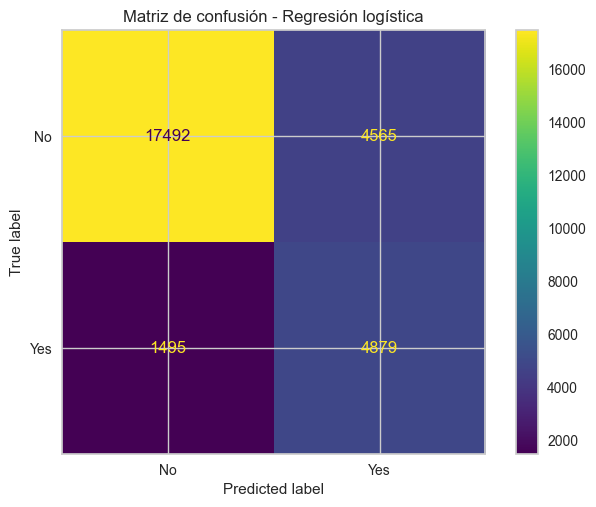

In [441]:
# graficamos la matriz de confusión para la regresión logística
cm_logistico = confusion_matrix(y_test, y_pred_logistico)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_logistico,display_labels=["No", "Yes"])

disp.plot()
plt.title("Matriz de confusión - Regresión logística")
plt.show()

In [442]:
# extraemos los valores de la matriz de confusión
vn, fp, fn, vp = cm_logistico.ravel()

print("Verdaderos negativos:", vn)
print("Falsos positivos:", fp)
print("Falsos negativos:", fn)
print("Verdaderos positivos:", vp)

Verdaderos negativos: 17492
Falsos positivos: 4565
Falsos negativos: 1495
Verdaderos positivos: 4879


La matriz de confusión muestra que el modelo clasifica correctamente una gran cantidad de días sin lluvia, con 20862 verdaderos negativos. También detecta 3239 días lluviosos correctamente.

Sin embargo, se observan 3135 falsos negativos, es decir días en los que realmente llovió pero el modelo predijo que no llovería. Este valor es importante porque indica que el modelo todavía pierde una cantidad considerable de casos de lluvia.

También aparecen 1195 falsos positivos que corresponden a días en los que el modelo predijo lluvia pero finalmente no llovió. En este problema, los falsos positivos representan falsas alarmas, mientras que los falsos negativos representan lluvias no detectadas.

Esta matriz confirma lo que observamos en las métricas, el modelo tiene una buena accuracy general, pero el recall de la clase "Yes" es moderado, ya que no logra detectar todos los días lluviosos.

### Curva ROC y AUC

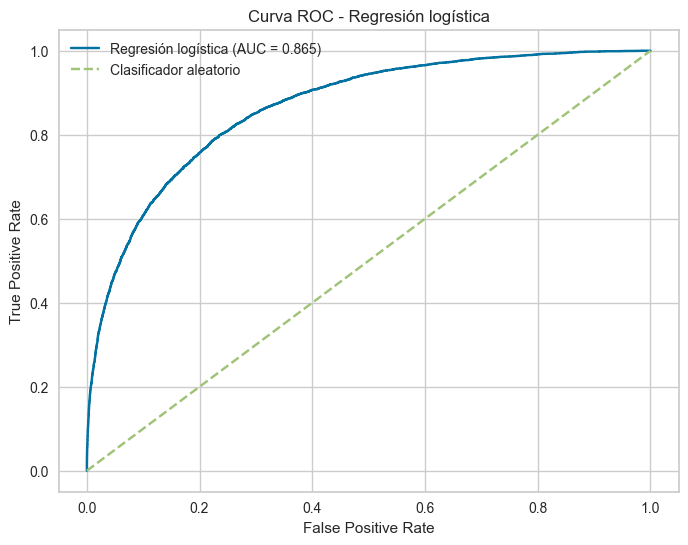

In [443]:
# Calculamos la curva ROC para la regresión logística.
fpr_logistico, tpr_logistico, thresholds_logistico = roc_curve(y_test,y_proba_logistico)

plt.figure(figsize=(8, 6))
plt.plot(fpr_logistico,tpr_logistico,label=f"Regresión logística (AUC = {auc_logistico:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Clasificador aleatorio")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Regresión logística")
plt.legend()
plt.show()

 El ROC-AUC fue de 0.870 lo cual indica que las probabilidades del modelo separan bastante bien los casos de lluvia y no lluvia, por eso el problema no necesariamente está en que el modelo no sirva, sino en que el umbral 0.5 puede no ser el más conveniente si queremos detectar más días de lluvia. Bajar el umbral podría aumentar el recall para detectar más lluvias reales pero la desventaja es que también podrían aumentar los falsos positivos

### Análisis del umbral de decisión

In [444]:
# buscamos un umbral posible maximizando la diferencia entre TPR y FPR
indice_mejor_umbral = np.argmax(tpr_logistico - fpr_logistico)
mejor_umbral = thresholds_logistico[indice_mejor_umbral]

print("Mejor umbral sugerido:", mejor_umbral)
print("TPR:", tpr_logistico[indice_mejor_umbral])
print("FPR:", fpr_logistico[indice_mejor_umbral])

Mejor umbral sugerido: 0.46137963320674813
TPR: 0.7987135236899906
FPR: 0.2349367547717278


In [445]:
# generamos nuevas predicciones usando el umbral sugerido
y_pred_logistico_umbral = (y_proba_logistico >= mejor_umbral).astype(int)

print(classification_report(y_test, y_pred_logistico_umbral))

              precision    recall  f1-score   support

           0       0.93      0.77      0.84     22057
           1       0.50      0.80      0.61      6374

    accuracy                           0.77     28431
   macro avg       0.71      0.78      0.73     28431
weighted avg       0.83      0.77      0.79     28431



Con este nuevo umbral, el recall de la clase "Yes" aumenta de aproximadamente 0.51 a 0.80. Esto significa que el modelo detecta una mayor proporción de los días en los que realmente llueve. La precision de la clase "Yes" es 0.50 y la accuracy general disminuye a 0.78, esto pasa porque al bajar el umbral el modelo clasifica más casos como lluvia, lo que reduce los falsos negativos pero aumenta los falsos positivos.

Si se prioriza no perder lluvias reales conviene un umbral menor y si se prioriza evitar falsas alarmas conviene un umbral más alto.

## Ítem 3: Implementación de modelo base

In [446]:
# implementamos modelo base con "DummyClassifier", predice siempre el que tiene mas frecuencia
modelo_base = Pipeline(steps=[
    ("preprocesamiento", preprocesamiento),
    ("clasificador", DummyClassifier(strategy="most_frequent", random_state=42))
    ])

modelo_base.fit(X_train, y_train)
y_pred_base = modelo_base.predict(X_test)

In [447]:
# calculamos métricas principales para evaluar el modelo base basado en frecuencia
accuracy_base = accuracy_score(y_test, y_pred_base)
precision_base = precision_score(y_test, y_pred_base, zero_division=0)
recall_base = recall_score(y_test, y_pred_base, zero_division=0)
f1_base = f1_score(y_test, y_pred_base, zero_division=0)
auc_base = roc_auc_score(y_test, y_pred_base)

print("Accuracy:", accuracy_base)
print("Precision:", precision_base)
print("Recall:", recall_base)
print("F1-score:", f1_base)
print("ROC-AUC:", auc_base)

Accuracy: 0.7758080967957511
Precision: 0.0
Recall: 0.0
F1-score: 0.0
ROC-AUC: 0.5


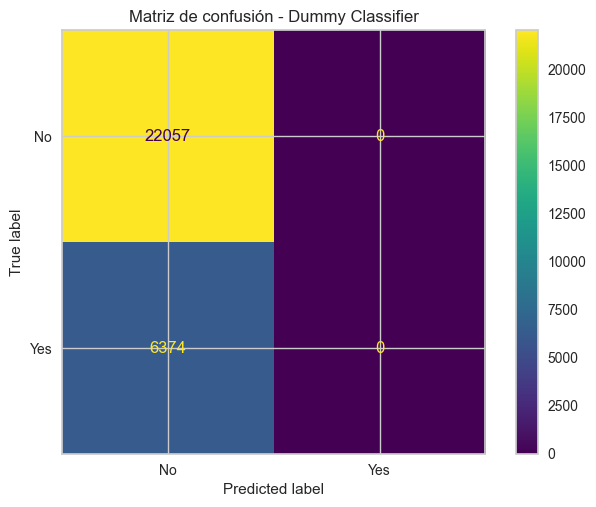

In [448]:
# graficamos la matriz de confusión para la regresión logística
cm_base = confusion_matrix(y_test, y_pred_base)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_base,display_labels=["No", "Yes"])

disp.plot()
plt.title("Matriz de confusión - Dummy Classifier")
plt.show()

In [449]:
# extraemos los valores de la matriz de confusión
vn, fp, fn, vp = cm_base.ravel()

print("Verdaderos negativos:", vn)
print("Falsos positivos:", fp)
print("Falsos negativos:", fn)
print("Verdaderos positivos:", vp)

Verdaderos negativos: 22057
Falsos positivos: 0
Falsos negativos: 6374
Verdaderos positivos: 0


La matriz de confusión del modelo base muestra que el clasificador predice siempre la clase mayoritaria, es decir, No. Por eso clasifica correctamente los días sin lluvia, pero no detecta ningún caso de lluvia.
Esto confirma que la accuracy no alcanza para evaluar este problema, ya que un modelo puede obtener un valor aparentemente aceptable simplemente prediciendo siempre la clase más frecuente.

Modelo Base: si llovió hoy, llueve mañana

In [450]:

df_rain_train = X_train[["RainToday"]].copy()
df_rain_train["RainTomorrow"] = y_train.map({0: "No", 1: "Yes"})

# eliminamos filas donde RainToday sea nulo para observar la relación de forma directa
df_rain_train = df_rain_train.dropna(subset=["RainToday"])

tabla_rain_pct = pd.crosstab(
    df_rain_train["RainToday"],
    df_rain_train["RainTomorrow"],
    normalize="index"
) * 100

tabla_rain_pct = tabla_rain_pct.reindex(columns=["No", "Yes"])
tabla_rain_pct.round(2)

RainTomorrow,No,Yes
RainToday,,
No,84.43,15.57
Yes,53.42,46.58


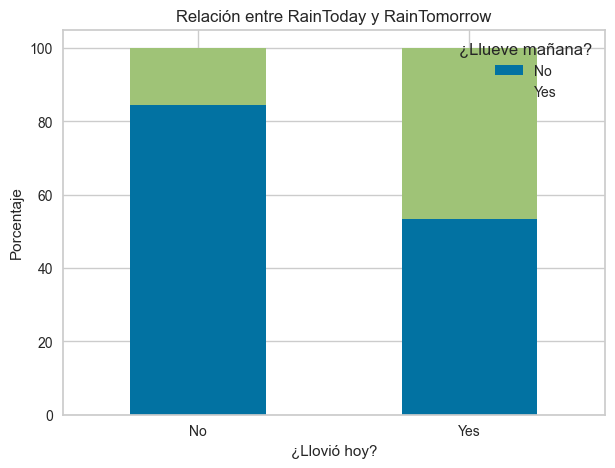

In [451]:
tabla_rain_pct.plot(kind="bar", stacked=True, figsize=(7, 5))

plt.title("Relación entre RainToday y RainTomorrow")
plt.xlabel("¿Llovió hoy?")
plt.ylabel("Porcentaje")
plt.xticks(rotation=0)
plt.legend(title="¿Llueve mañana?")
plt.show()

En este caso, vemos que:
* Cuando no llueve en el día es muy probable que al día siguiente tampoco llueva
* Para los dias que llovió, aunque se acerca un poco en su mayoria, tampoco llueve al dia siguiente

Este modelo debería superar al anterior, predice lluvia para algunos casos en lugar de simplemente predecir que no llueve

In [452]:
# implementamos un modelo base basado en una regla simple:
# si RainToday = Yes, predecimos RainTomorrow = Yes; si RainToday = No, predecimos RainTomorrow = No

moda_raintoday_train = X_train["RainToday"].mode()[0]

y_pred_base_raintoday = (
    X_test["RainToday"]
    .fillna(moda_raintoday_train)
    .map({"No": 0, "Yes": 1})
    .astype(int)
)

In [453]:
# calculamos métricas principales para evaluar el modelo base basado en RainToday
accuracy_base_raintoday = accuracy_score(y_test, y_pred_base_raintoday)
precision_base_raintoday = precision_score(y_test, y_pred_base_raintoday, zero_division=0)
recall_base_raintoday = recall_score(y_test, y_pred_base_raintoday, zero_division=0)
f1_base_raintoday = f1_score(y_test, y_pred_base_raintoday, zero_division=0)
auc_base_raintoday = roc_auc_score(y_test, y_pred_base_raintoday)

print("Accuracy:", accuracy_base_raintoday)
print("Precision:", precision_base_raintoday)
print("Recall:", recall_base_raintoday)
print("F1-score:", f1_base_raintoday)
print("ROC-AUC:", auc_base_raintoday)

Accuracy: 0.7569906088424607
Precision: 0.45776093478604135
Recall: 0.45481644179479136
F1-score: 0.45628393798693634
ROC-AUC: 0.6495644524792065


El baseline basado en la variable raintoday tiene un poco menor Accuracy que la que predice "No" pero aumenta precision y recall ya que predice positivo para algunos casos.

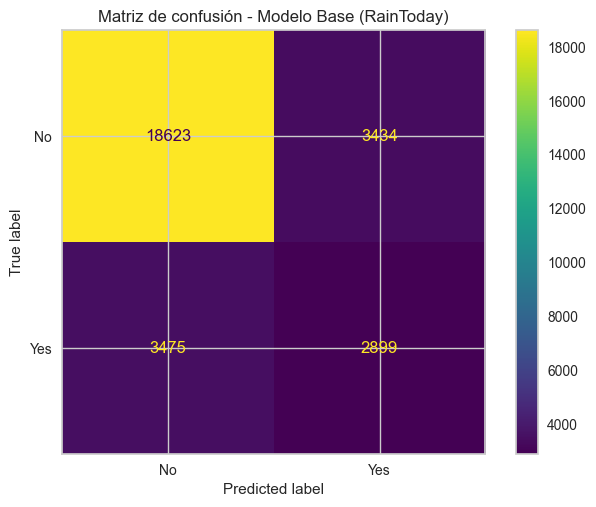

In [454]:
# graficamos la matriz de confusión para la regresión logística
cm_rain_today = confusion_matrix(y_test, y_pred_base_raintoday)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rain_today,display_labels=["No", "Yes"])

disp.plot()
plt.title("Matriz de confusión - Modelo Base (RainToday)")
plt.show()

In [455]:
# extraemos los valores de la matriz de confusión
vn, fp, fn, vp = cm_rain_today.ravel()

print("Verdaderos negativos:", vn)
print("Falsos positivos:", fp)
print("Falsos negativos:", fn)
print("Verdaderos positivos:", vp)

Verdaderos negativos: 18623
Falsos positivos: 3434
Falsos negativos: 3475
Verdaderos positivos: 2899


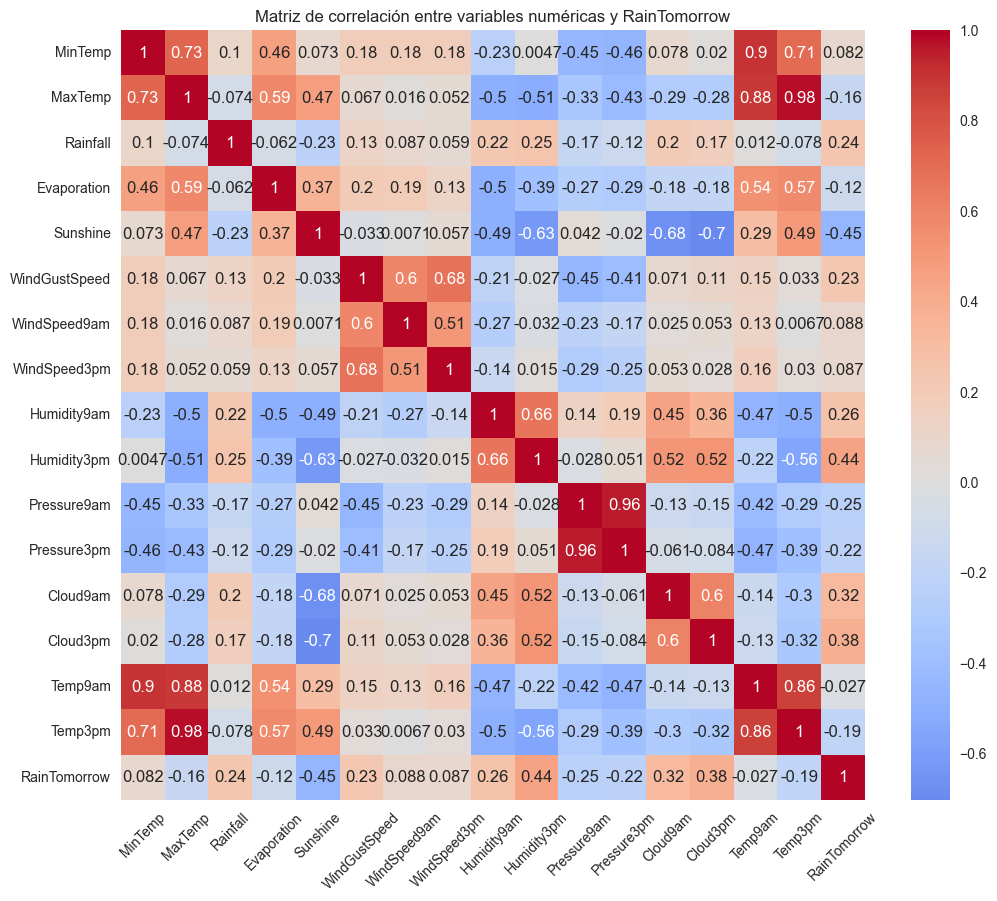

In [456]:
# copiamos las variables numéricas
df_corr = df_train[columnas_numericas].copy()

# agregamos el target codificado como variable binaria
df_corr["RainTomorrow"] = y_train

# calculamos la matriz de correlación incluyendo el target
correlacion2 = df_corr.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlacion2, cmap="coolwarm", center=0, annot=True)
plt.title("Matriz de correlación entre variables numéricas y RainTomorrow")
plt.xticks(rotation=45)
plt.show()

Elegimos usar la variable Sunshine para la regresion logistica de 1 variable

In [457]:
X_train_variable_unica = X_train[['Sunshine']]
X_test_unica = X_test[['Sunshine']]
#Ya que el dataset esta desbalanceado vamos a usar class_weight="balanced" para que el modelo le de más peso a la clase minoritaria
# creamos un Pipeline que combina el preprocesamiento y la regresión logística
modelo_logistico_una_var = Pipeline(steps=[
    ("preprocesamiento", preprocesamiento_numerico),
    ("clasificador", LogisticRegression(max_iter=1000, random_state=42,class_weight="balanced"))
])

# entrenamos el modelo utilizando el conjunto de entrenamiento
modelo_logistico_una_var.fit(X_train_variable_unica, y_train)

# obtenemos las predicciones de clase sobre el conjunto de prueba
y_pred_una_var = modelo_logistico_una_var.predict(X_test_unica)

# obtenemos las probabilidades de pertenecer a la clase positiva
y_proba_logistico_una_var = modelo_logistico_una_var.predict_proba(X_test_unica)[:, 1]


In [458]:
# calculamos métricas principales para evaluar el modelo de regresión logística
accuracy_logistico = accuracy_score(y_test, y_pred_una_var)
precision_logistico = precision_score(y_test, y_pred_una_var)
recall_logistico = recall_score(y_test, y_pred_una_var)
f1_logistico = f1_score(y_test, y_pred_una_var)
auc_logistico = roc_auc_score(y_test, y_proba_logistico_una_var)

print("Accuracy:", accuracy_logistico)
print("Precision:", precision_logistico)
print("Recall:", recall_logistico)
print("F1-score:", f1_logistico)
print("ROC-AUC:", auc_logistico)

Accuracy: 0.6785902711828637
Precision: 0.3624328090782401
Recall: 0.5712268591151554
F1-score: 0.44348355663824607
ROC-AUC: 0.7083718498179241


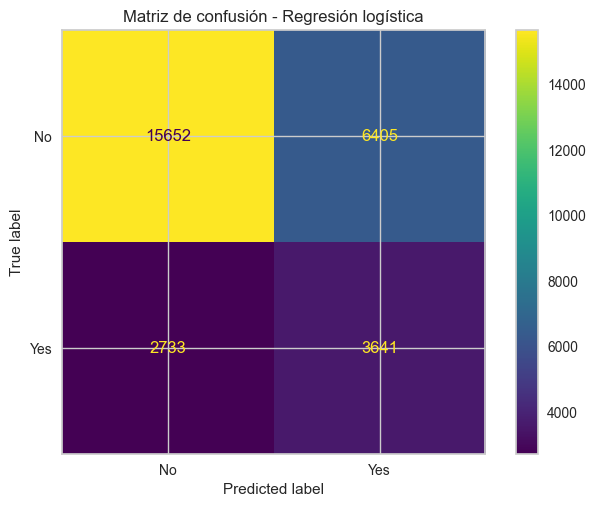

In [459]:
# graficamos la matriz de confusión para la regresión logística
cm_una_var = confusion_matrix(y_test, y_pred_una_var)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_una_var,display_labels=["No", "Yes"])

disp.plot()
plt.title("Matriz de confusión - Regresión logística")
plt.show()

In [460]:
# extraemos los valores de la matriz de confusión
vn, fp, fn, vp = cm_una_var.ravel()

print("Verdaderos negativos:", vn)
print("Falsos positivos:", fp)
print("Falsos negativos:", fn)
print("Verdaderos positivos:", vp)

Verdaderos negativos: 15652
Falsos positivos: 6405
Falsos negativos: 2733
Verdaderos positivos: 3641


La regresión logística con todas las variables supera a los modelos base porque, además de mantener una accuracy mayor, logra identificar una parte de los días con lluvia. Esto se observa especialmente en el recall y el F1-score de la clase positiva.

Por lo tanto, la regresión logística aporta valor respecto de una estrategia ingenua basada solamente en predecir siempre la clase mayoritaria, basada en el valor de una variable o la regresión logística de una sola variable.

## Ítem 4: Optimización de hiperparámetros

Optimizaremos:
* C porque controla la regularización, entonces probamos un rango amplio para  encontrar el equilibrio que mejor generalice y evitar overfitting
* class_weight, porque permite ajustar el peso de cada clase durante el entrenamiento e incluímos balanced para que el modelo no ignore la clase minoritaria (lluvia), por estar desbalanceado el dataset
  
  

In [461]:
# Grid search

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_params = {
    'clasificador__C': [0.01, 0.1, 1, 10, 100, 1000, 10000], # 7 valores
    'clasificador__class_weight': [None, 'balanced'] # 2 valores
}

# 7*2 = 14 combinaciones de hiperparámetros
# utilizamos 5 splits, entonces:
# nro. de entrenamientos = 5 * 14 = 70

modelo_grid = Pipeline(steps=[
    ("preprocesamiento", preprocesamiento),
    ("clasificador", LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42))
])

grid_search = GridSearchCV(
    modelo_grid, grid_params, cv=cv, scoring='f1', n_jobs=-1
)

grid_search.fit(X_train, y_train)
best_grid_model = grid_search.best_estimator_
grid_search_f1 = f1_score(y_test, best_grid_model.predict(X_test))
accuracy_grid = accuracy_score(y_test, best_grid_model.predict(X_test))
precision_grid = precision_score(y_test, best_grid_model.predict(X_test))
recall_grid = recall_score(y_test, best_grid_model.predict(X_test))

Utilizamos validación cruzada para obtener una mejor estimación de F1-score. Promediamos los scores sobre distintas partes (folds) del dataset. Luego aplicamos StratifiedKFold para que las clases queden proporcionadas en cada fold, así evitamos cualquier sesgo en los datos

Elegimos grid search por sobre las otras dos opciones porque el espacio de parámetros es muy pequeño (14 combinaciones) y en estos casos grid search es más eficiente y consume menos recursos para realizar la búsqueda que Optuna o Random Search

In [462]:
print("Mejores parámetros:", grid_search.best_params_)
print("Mejor score:", grid_search.best_score_)
print("Accuracy:", accuracy_grid)
print("Precision:", precision_grid)
print("Recall:", recall_grid)
print("F1-score:", grid_search_f1)

Mejores parámetros: {'clasificador__C': 10, 'clasificador__class_weight': 'balanced'}
Mejor score: 0.6183974855222638
Accuracy: 0.786817206570293
Precision: 0.5165731229482156
Recall: 0.7652965171007217
F1-score: 0.6168047037997092


Optimizando los hiperparámetros del modelo con grid search, logramos un F1-score de 0.62 en test, superando al dummy (F1 = 0) y al modelo base asumiendo que si llovió hoy, llueve mañana (F1 = 0.45)

La mejora respecto al modelo de regresión logística del item 2 (F1 = 0.59) es muy poca, lo que sugiere que ya alcanzamos el límite del modelo de regresión logística con este dataset

In [463]:
best_grid_model

Pipeline(memory=None,
         steps=[('preprocesamiento',
                 ColumnTransformer(n_jobs=None, remainder='drop',
                                   sparse_threshold=0.3,
                                   transformer_weights=None,
                                   transformers=[('num',
                                                  Pipeline(memory=None,
                                                           steps=[('scaler',
                                                                   StandardScaler(copy=True,
                                                                                  with_mean=True,
                                                                                  with_std=True))],
                                                           verbose=False),
                                                  Index(['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
       'WindGustSpeed'...
                                                  Index(['WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday', 'Season'], dtype='object'))],
                                   verbose=False,
                                   verbose_feature_names_out=True)),
                ('clasificador',
                 LogisticRegression(C=10, class_weight='balanced', dual=False,
                                    fit_intercept=True, intercept_scaling=1,
                                    l1_ratio=None, max_iter=1000,
                                    multi_class='auto', n_jobs=None,
                                    penalty='l2', random_state=42,
                                    solver='lbfgs', tol=0.0001, verbose=0,
                                    warm_start=False))],
         verbose=False)

In [464]:
preprocesamiento = best_grid_model.named_steps['preprocesamiento'] # ColumnTransformer
clasificador = best_grid_model.named_steps['clasificador'] # LogisticRegression

Desempaquetamos el pipeline, extrayendo preprocesador y clasificador

In [465]:
X_train_scaled = preprocesamiento.transform(X_train)
X_test_scaled = preprocesamiento.transform(X_test)

Transformamos los datos para que Shap los reciba preprocesados como el clasificador del pipeline (pasan de df a array)

In [466]:
OHE = preprocesamiento.named_transformers_["cat"].named_steps["encoder"]
columnas_categoricas_ohe = OHE.get_feature_names_out(columnas_categoricas)
feature_names = list(columnas_numericas) + list(columnas_categoricas_ohe)

Obtenemos el nombre de todas las columnas, numéricas + categóricas expandidas por OneHotEncoder

## Ítem 5: Explicabilidad de modelos mediante SHAP

In [467]:
# Crea un objeto explainer SHAP
explainer = shap.LinearExplainer(clasificador, X_train_scaled, feature_names=feature_names)

# Calcula los valores SHAP para un conjunto de ejemplos de prueba
shap_values = explainer.shap_values(X_test_scaled)

In [468]:
print(explainer.expected_value)

-0.5996091966768091


El modelo predice (sin tener en cuenta las features) que hay más probabilidad que el día siguiente a la medición no llueva

In [469]:
shap_values.shape

(28431, 70)

In [470]:
shap_values[0]

array([-2.82178779e-02, -9.78088568e-02, -2.34460149e-02, -1.14375225e-03,
        1.31461262e-02, -4.92049269e-01,  1.05926614e-01,  2.59695047e-01,
       -2.93149321e-02, -9.34101594e-01, -3.42217695e-01,  4.46289210e-01,
       -1.15877329e-04, -3.71743990e-03, -2.71623199e-02,  7.00297809e-02,
        8.50328648e-03,  7.86123308e-03,  1.68663278e-03, -6.59752379e-04,
       -1.45353445e-01,  8.82582468e-03, -2.98258708e-04, -4.51483249e-03,
       -2.99116526e-03, -8.34907939e-03, -4.65839744e-03, -2.84963726e-04,
        3.16938073e-03, -4.02611747e-03,  5.02229580e-03, -3.14894094e-04,
       -3.28316696e-03, -1.15575582e-02,  1.84071685e-02, -7.58323604e-03,
       -8.90928591e-03, -1.61356955e-02,  5.53205704e-03,  1.13424924e-04,
        1.67069202e-02,  6.73196410e-03,  8.54717418e-03,  4.63031527e-03,
       -8.77085145e-04, -2.26887551e-02, -5.25691881e-04,  0.00000000e+00,
        4.24252548e-03,  1.75352840e-02,  6.50572696e-03, -8.97900696e-03,
        8.76080778e-03,  

Gráficas a nivel local

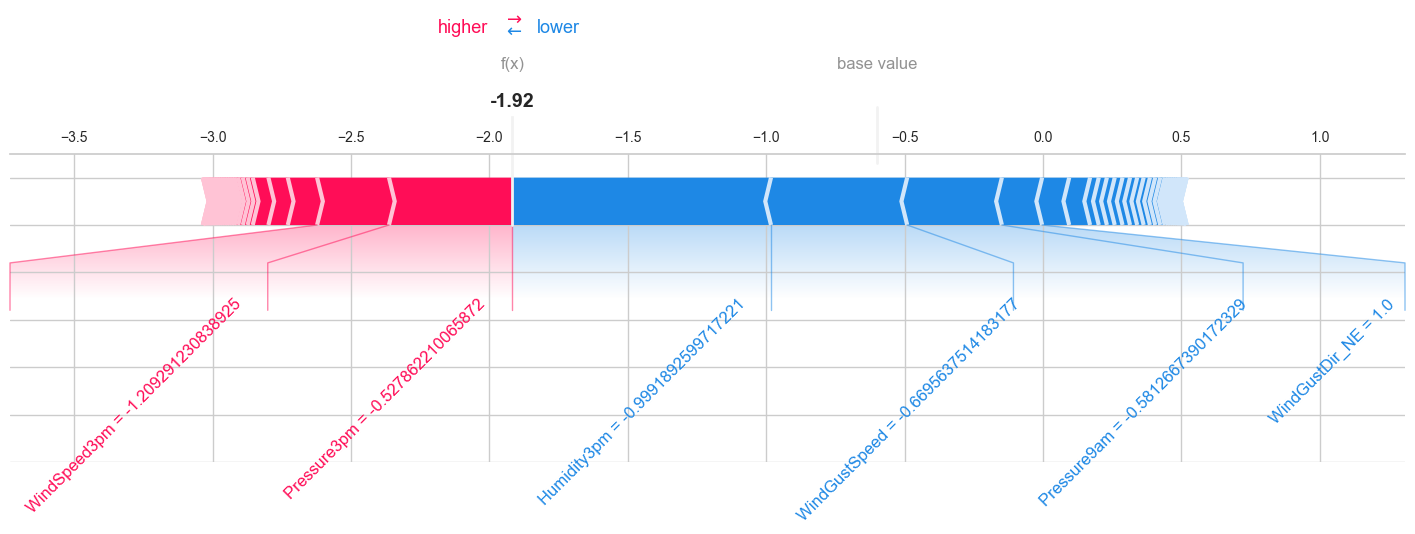

In [471]:
index=0
shap.force_plot(explainer.expected_value, shap_values[index], X_test_scaled[index],
feature_names=feature_names, matplotlib=True, figsize=(18, 4),
text_rotation=45)

Vemos que para la primer medición del set de test, las features empujan la predicción desde el valor base (aprox. -0.6), hasta -1.86.

Las features que indican que no va a llover mañana tienen mayor peso que las features que indican que lloverá, es poco probable que llueva el día siguiente a la medición.

El valor que obtuvimos es logit = -1.86 (logaritmo de las chances). Podemos pasarlo a probabilidad con la fórmula p(x) = 1 / (1 + e^-(logit)).  En este caso, p(x) = 0.134 (13.4% de probabilidad de lluvia el día posterior a la medición)

In [472]:
explanation = shap.Explanation(values=shap_values[index], base_values=explainer.expected_value, feature_names=feature_names)

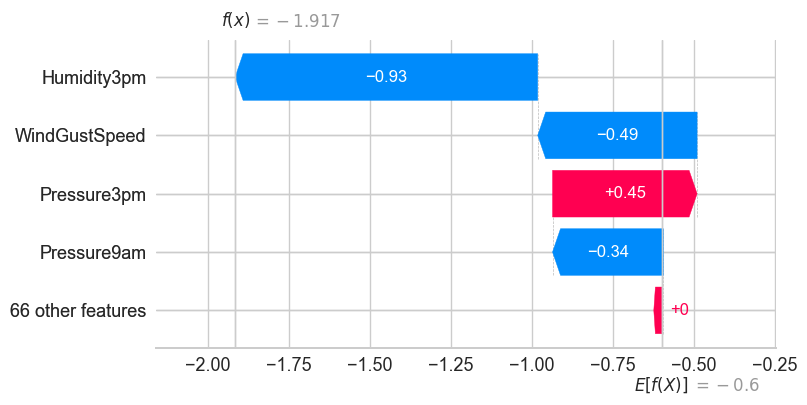

In [473]:
shap.plots.waterfall(explanation, max_display=5)

Partimos de E[f(x)] = -0.612 (valor base):
* La humedad a las 3pm se inclina mucho hacia predicciones de "no lloverá mañana"
* La presión a las 9am está asociada a menor probabilidad de lluvia

* Luego, la presión a las 3pm está asociada a una mayor probabilidad de lluvia, y en menor medida otras 66 features

La predicción final es f(x) = -1.862 (13.4% de probabilidad de lluvia el día posterior a la medición)

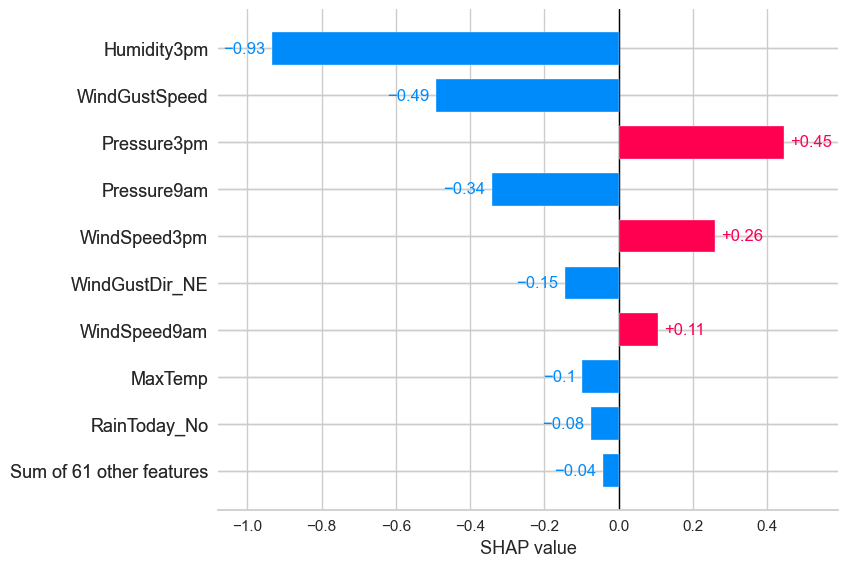

In [474]:
shap.plots.bar(explanation)

* Las features que más empujan la predicción hacia "llueve" son Pressure3pm (+0.42), WindSpeed3pm (+0.24) y WindSpeed9am (+0.11).

* Las features que más empujan la predicción hacia "no lloverá" son Humidity3pm (-0.95), WindGustSpeed (-0.49) y Pressure9am (-0.33).

Las otras 61 features aportan poca información individualmente para resolver la incertidumbre sobre si mañana llueve o no, pero en conjunto empujan la predicción hacia "no lloverá" (-0.12)




Gráficas a nivel global

In [475]:
explanation = shap.Explanation(values=shap_values, base_values=explainer.expected_value, feature_names=feature_names, data=X_test_scaled)

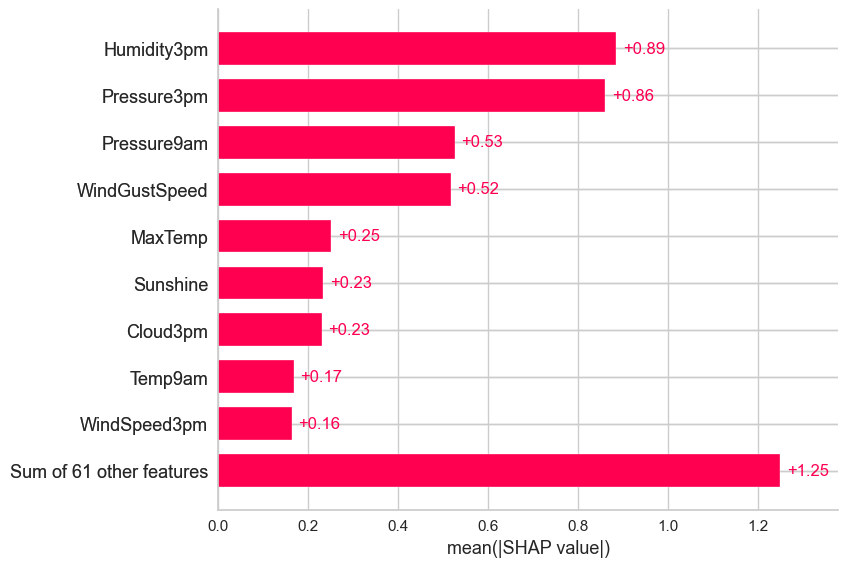

In [476]:
shap.plots.bar(explanation)

El bar plot global nos indica el peso en promedio de cada feature en todo el dataset de prueba, pero no nos indica el sentido de cada feature, si empuja hacia "lloverá" o "no lloverá".

Vemos que las features con más peso del modelo son la humedad a la 3pm, presión a las 3pm, velocidad de ráfagas de viento, presión a las 9am y temperatura máxima del día donde se registró la medición, entre otras. Mientras que otras 61 features con poco peso individual, en conjunto aportan bastante información para la predicción.

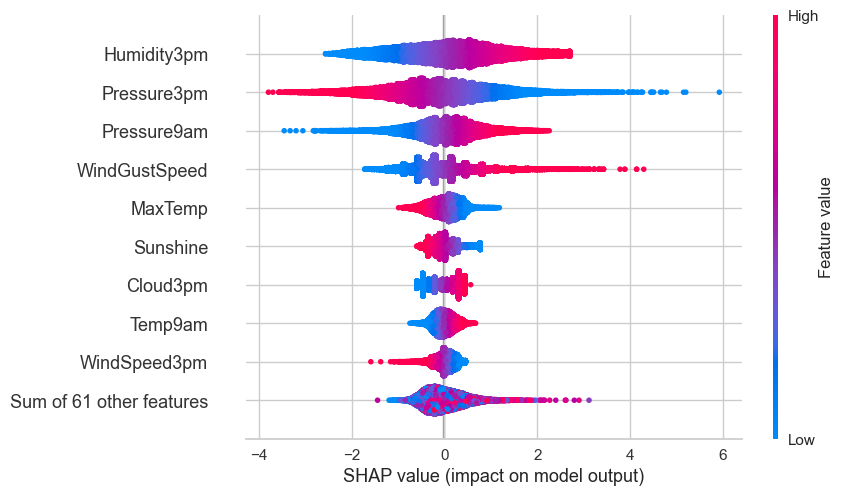

In [477]:
shap.plots.beeswarm(explanation)

A fin de interpretar el beeswarm plot, analizaremos las 5 primeras features:

Humedad a las 3pm:
* poca humedad ambiente -> se asocia con menor probabilidad de lluvia
* mucha humedad ambiente -> se asocia con mayor probabilidad de lluvia

Presión atmosférica a las 3pm:
* baja presión atmosférica -> se asocia con mayor probabilidad de lluvia
* alta presión atmosférica -> se asocia con menor probabilidad de lluvia

Velocidad de las ráfagas de viento:
* Ráfagas de pocos km/h -> se asocian a menor probabilidad de lluvia
* Ráfagas veloces -> se asocian a mayor probabilidad de lluvia

Presión atmosférica a las 9am:
* baja presión atmosférica matutina -> se asocia con menor probabilidad de lluvia
* alta presión atmosférica matutina -> se asocia con mayor probabilidad de lluvia

Temperatura máxima del día: vemos que está muy concentrada en valores cercanos al 0, lo que indica que no aporta mucha información sobre si lloverá o no, pero en general, vemos un sesgo que indica:
* Una temperatura máxima baja está asociado a una mayor probabilidad de lluvia el día siguiente
* Una temperatura máxima alta está asociado a una menor probabilidad de lluvia el día siguiente

## Ítem 6: AutoML con PyCaret

In [478]:
# Creamos un dataset de entrenamiento para PyCaret uniendo X_train con y_train
df_pycaret_train = X_train.copy()
df_pycaret_train["RainTomorrow"] = y_train

# Creamos un dataset de prueba con los datos que ya habíamos separado
df_pycaret_test = X_test.copy()
df_pycaret_test["RainTomorrow"] = y_test

df_pycaret_train.head()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,...,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,Region,Season,RainTomorrow
63909,-0.043450,0.306861,-0.273691,-0.471938,-0.213143,WSW,2.888202,W,NW,2.029317,...,-0.316714,-0.423987,-0.152137,-0.479947,-0.148366,0.387624,No,5,Spring,0
87162,0.314692,-0.043913,2.627483,-0.300905,-1.393811,SE,-0.291078,SW,SSE,-0.789026,...,1.094236,0.941231,0.540361,0.917059,0.143495,-0.001618,Yes,6,Winter,0
90232,1.077690,0.657634,-0.273691,0.585477,0.606766,ESE,0.087408,S,SE,1.127447,...,0.109511,0.080550,0.039760,0.009487,1.049801,0.560621,No,6,Summer,0
88210,1.311260,1.022439,-0.273691,0.364224,0.147617,E,-0.669564,SSE,E,0.225577,...,-0.772333,-0.794970,0.886611,1.284692,1.464551,0.848948,No,3,Spring,0
71438,1.451403,2.004605,-0.273691,1.551955,-0.442717,NW,0.087408,NW,WSW,-0.338091,...,-0.698846,-0.513023,0.886611,0.917059,1.817856,1.930176,No,0,Summer,0


Usamos los mismos conjuntos de entrenamiento y prueba que en los ítems anteriores. Esto es importante porque permite comparar los resultados de PyCaret contra los modelos ya entrenados de manera justa, sin cambiar los datos usados para evaluar.

In [479]:
# Configuramos el experimento de clasificación
experimento_pycaret = setup(data=df_pycaret_train,target="RainTomorrow", session_id=42, train_size=0.8, normalize=True, fix_imbalance=True, fold=5, verbose=False)

Comparamos varios modelos automáticamente usando F1-score como métrica principal. Para evitar un tiempo de cómputo elevado nos limitamos a lr, dt, rf, ada y gbc.

In [480]:
mejor_modelo_pycaret = compare_models(
    sort="F1",
    include=["lr", "dt", "rf", "ada", "gbc"]
)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
rf,Random Forest Classifier,0.8466,0.8798,0.6281,0.6679,0.6474,0.5495,0.5499,4.6880
gbc,Gradient Boosting Classifier,0.8220,0.8650,0.6781,0.5896,0.6307,0.5142,0.5164,10.9080
lr,Logistic Regression,0.7875,0.8640,0.7668,0.5176,0.6180,0.4783,0.4961,1.2680
ada,Ada Boost Classifier,0.7964,0.8484,0.7030,0.5351,0.6077,0.4736,0.4817,3.5120
dt,Decision Tree Classifier,0.7679,0.7004,0.5780,0.4852,0.5275,0.3752,0.3778,1.7200


In [481]:
mejor_modelo_pycaret

RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='gini', max_depth=None, max_features='sqrt',
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.0, min_samples_leaf=1,
                       min_samples_split=2, min_weight_fraction_leaf=0.0,
                       monotonic_cst=None, n_estimators=100, n_jobs=-1,
                       oob_score=False, random_state=42, verbose=0,
                       warm_start=False)

PyCaret comparó automáticamente distintos modelos de clasificación y los ordenó según F1-score, que fue la métrica elegida. El mejor modelo según PyCaret fue Random Forest, con un F1-score de 0.6357 y un AUC de 0.8828. Esto indica que tuvo el mejor equilibrio general entre precision y recall dentro de los modelos evaluados. También se observa que Logistic Regression obtuvo el mayor recall, con 0.7681. Esto significa que detecta una mayor cantidad de días con lluvia, pero a costa de una precision más baja, es decir, genera más falsos positivos, Random Forest en cambio tiene una precision más alta y un F1-score superior, por lo que logra un mejor balance entre detectar lluvia y evitar falsas alarmas.
Decision Tree fue el modelo con peor rendimiento general, con menor F1-score y menor AUC, lo que indica que un árbol individual no generaliza tan bien como modelos más robustos como Random Forest o Gradient Boosting

In [482]:
# Se toma como modelo final el mejor modelo seleccionado por PyCaret
modelo_pycaret_final = mejor_modelo_pycaret

In [483]:
# Evaluamos el modelo elegido por PyCaret sobre el conjunto de prueba externo
predicciones_pycaret = predict_model(modelo_pycaret_final, data=df_pycaret_test)

predicciones_pycaret.head()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Random Forest Classifier,0.8455,0.8812,0.6252,0.6653,0.6446,0.5460,0.5464


,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,...,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,Region,Season,RainTomorrow,prediction_label,prediction_score
3114,-0.354877,0.405077,-0.273691,-0.189015,-0.081957,NE,-0.669564,W,NNE,-1.578162,...,-0.008523,0.031071,-0.086922,0.459706,No,2,Autumn,0,0,0.92
120716,-0.666305,-0.380656,-0.250294,-0.158377,1.098711,SW,-0.745261,ENE,SW,-0.901760,...,0.540361,-1.288740,0.005245,-0.131365,No,1,Spring,0,0,0.95
62856,-0.744162,-0.338563,-0.273691,0.031660,1.623452,ESE,0.087408,N,E,-0.789026,...,-0.844635,-1.656373,-0.378783,-0.102532,No,5,Spring,0,0,0.91
66599,-0.027878,-0.184223,-0.273691,0.174188,-0.081957,SSE,0.163105,SW,SSE,0.225577,...,0.886611,0.181793,-0.486311,-0.376443,No,5,Spring,0,0,0.90
111484,0.267978,-0.717399,0.170844,-0.281901,0.311599,SSW,-0.291078,WSW,SW,0.676512,...,0.886611,0.402372,0.020606,0.041631,Yes,1,Autumn,1,1,0.55


In [484]:
predicciones_pycaret.columns

Index(['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
       'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'RainToday', 'Region', 'Season', 'RainTomorrow',
       'prediction_label', 'prediction_score'],
      dtype='object')

In [485]:
# Valores reales y predichos
y_true_pycaret = predicciones_pycaret["RainTomorrow"]
y_pred_pycaret = predicciones_pycaret["prediction_label"]

# Métricas
accuracy_pycaret = accuracy_score(y_true_pycaret, y_pred_pycaret)
precision_pycaret = precision_score(y_true_pycaret, y_pred_pycaret)
recall_pycaret = recall_score(y_true_pycaret, y_pred_pycaret)
f1_pycaret = f1_score(y_true_pycaret, y_pred_pycaret)

print("Accuracy:", accuracy_pycaret)
print("Precision:", precision_pycaret)
print("Recall:", recall_pycaret)
print("F1-score:", f1_pycaret)

Accuracy: 0.8454503886602652
Precision: 0.6652754590984975
Recall: 0.625196109193599
F1-score: 0.644613393723714


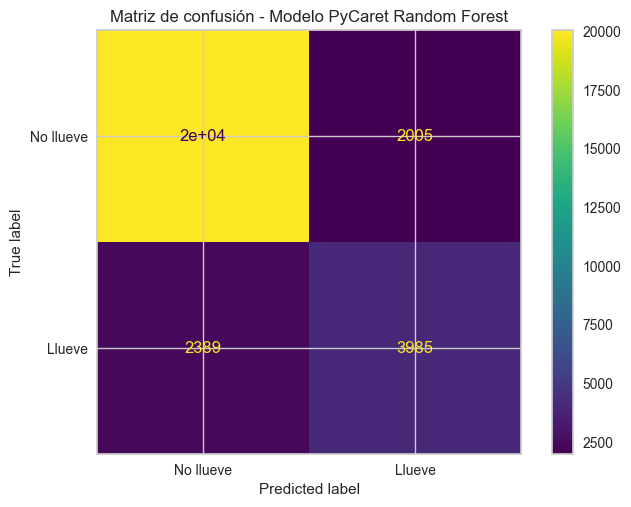

In [486]:
cm_pycaret = confusion_matrix(y_true_pycaret, y_pred_pycaret)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_pycaret,
    display_labels=["No llueve", "Llueve"]
)

disp.plot()
plt.title("Matriz de confusión - Modelo PyCaret Random Forest")
plt.show()

Al evaluar el modelo Random Forest seleccionado por PyCaret sobre el conjunto de prueba externo, se obtuvieron los siguientes resultados:

- Accuracy: 0.8518
- Precision: 0.7096
- Recall: 0.5736
- F1-score: 0.6344
- AUC: 0.8833

La matriz de confusión muestra que el modelo clasificó correctamente 20561 casos de "No llueve" y 3656 casos de "Llueve". También se observan 1496 falsos positivos, es decir días en los que el modelo predijo lluvia pero no llovió, y 2718 falsos negativos, es decir días en los que sí llovió pero el modelo predijo que no. En comparación con la regresión logística, PyCaret seleccionó un modelo con mejor F1-score y mejor AUC. Esto indica que Random Forest logra un mejor equilibrio general entre precision y recall pero la regresión logística tenía mayor recall, por lo que detectaba más días de lluvia, aunque generaba más falsos positivos.
Como el dataset está desbalanceado, no se toma accuracy como única métrica de decisión. En este caso se prioriza F1-score porque combina precision y recall, permitiendo evaluar mejor el rendimiento sobre la clase positiva, que corresponde a los días en los que llueve.

## Item 7: Implementación de red neuronal

In [487]:
# Separamos un conjunto de validación a partir del train escalado y lo usamos para entrenar la red neuronal
X_train_nn, X_valid_nn, y_train_nn, y_valid_nn = train_test_split(
    X_train_scaled, y_train,
    test_size=0.2, random_state=42, stratify=y_train
)

In [488]:
class NeuralNetwork:
    def __init__(self, epochs=50, batch_size=16, learning_rate=0.01, dropout_rate=0.0):
        # inicializamos parámetros de entrenamiento
        self.epochs = epochs
        self.batch_size = batch_size
        self.learning_rate = learning_rate
        self.dropout_rate = dropout_rate
        self.model = None

    def build_model(self, input_shape):
        # capas ocultas con relu, dropout para regularización, y salida sigmoid para clasificación binaria
        model = tf.keras.models.Sequential([
            tf.keras.layers.Dense(30, activation='relu', input_shape=(input_shape,)),
            tf.keras.layers.Dropout(self.dropout_rate),
            tf.keras.layers.Dense(26, activation='relu'),
            tf.keras.layers.Dropout(self.dropout_rate),
            tf.keras.layers.Dense(24, activation='relu'),
            tf.keras.layers.Dense(1, activation='sigmoid')
        ])
        # utilizamos binary_crossentropy como función de pérdida para clasificación binaria
        optimizer = tf.keras.optimizers.Adam(learning_rate=self.learning_rate)
        model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
        self.model = model

    def train(self, X_train, y_train, X_valid, y_valid):
        # Fit del modelo. Devuelve la evolución de la función de pérdida
        history = self.model.fit(X_train, y_train, validation_data=(X_valid, y_valid),
                                 epochs=self.epochs, batch_size=self.batch_size, verbose=0)
        return history.history['loss'], history.history['val_loss']

    def predict_probabilidad(self, X):
        # probabilidad de la clase positiva (lluvia)
        return self.model.predict(X, verbose=0).flatten()

    def predict(self, X, threshold=0.5):
        # umbral, aplica etiquetas 0 o 1 según la probabilidad
        return (self.predict_probabilidad(X) >= threshold).astype(int)

In [489]:
# construimos el modelo
nn = NeuralNetwork(epochs=200, batch_size=64, learning_rate=0.001, dropout_rate=0.3)
nn.build_model(input_shape=X_train_nn.shape[1])

# lo entrenamos
history_loss, history_val_loss = nn.train(X_train_nn, y_train_nn, X_valid_nn, y_valid_nn)

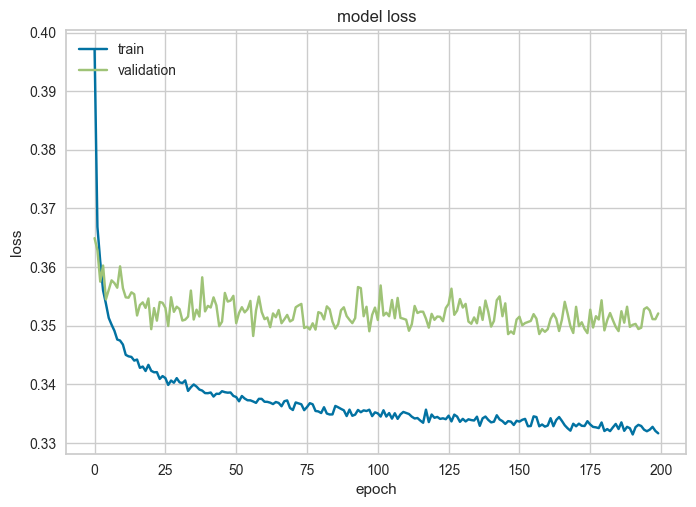

In [490]:
plt.plot(history_loss, label='train')
plt.plot(history_val_loss, label='validation')
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

Observamos un leve overfitting, ya que la train loss converge a 0.33 mientras la validation loss se estabiliza en promedio en 0.35

In [491]:
y_pred_nn = nn.predict(X_test_scaled)
y_probabilidad_nn = nn.predict_probabilidad(X_test_scaled)

# imprimimos las métricas principales
print(classification_report(y_test, y_pred_nn))
print(confusion_matrix(y_test, y_pred_nn))

              precision    recall  f1-score   support

           0       0.87      0.94      0.91     22057
           1       0.73      0.53      0.61      6374

    accuracy                           0.85     28431
   macro avg       0.80      0.74      0.76     28431
weighted avg       0.84      0.85      0.84     28431

[[20821  1236]
 [ 3000  3374]]


Observamos que la red neuronal alcanza un F1-score de 0.60 en la clase positiva (llueve), similar a la regresión logística sin optimizar (0.59) pero inferior a la regresión logística optimizada con grid search (0.62)

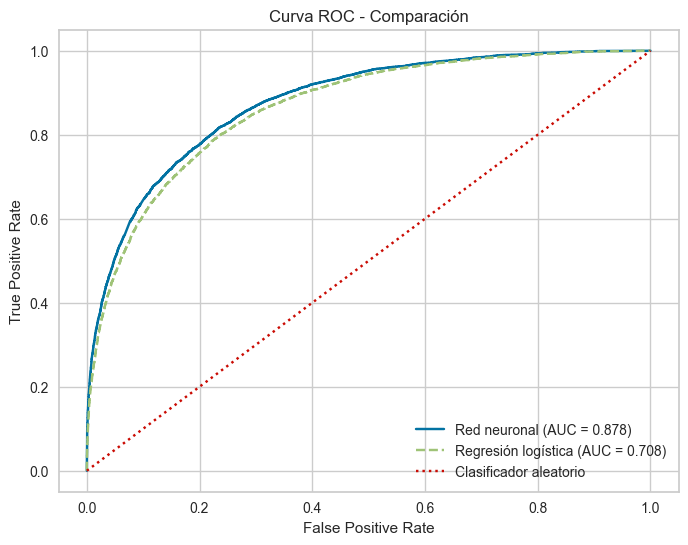

In [492]:
fpr_nn, tpr_nn, thresholds_nn = roc_curve(y_test, y_probabilidad_nn)
auc_nn = roc_auc_score(y_test, y_probabilidad_nn)

plt.figure(figsize=(8, 6))
plt.plot(fpr_nn, tpr_nn, label=f"Red neuronal (AUC = {auc_nn:.3f})")
plt.plot(fpr_logistico, tpr_logistico, label=f"Regresión logística (AUC = {auc_logistico:.3f})", linestyle='--')
plt.plot([0, 1], [0, 1], linestyle=":", label="Clasificador aleatorio")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Comparación")
plt.legend()
plt.show()

La red neuronal tiene un AUC más alto que la regresión logística. El valor cercano a 1 (ideal), indica que la red neuronal tiene buena capacidad para distinguir entre las clases "llueve" y no "llueve".